In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Physical parameters ( Table 1) ---
Lx , Ly = 600 *1e3 , 240* 1e3 # domain size [ m ]
Nx , Ny = 256 , 102 # grid resolution
g_prime = 0.3 # reduced gravity [ m / s ^2]
H0 = 1000.0 # mean layer depth [ m ]
U0 = 8.0 # inflow wind speed [ m / s ]
R0 = 20 *1e3 # island radius [ m ]
Cd = 0.02 # drag coefficient [1/ s ]
nu = 1000.0 # eddy viscosity [ m ^2/ s ]
dt = 30.0 # time step [ s ]
# --- Grid : x has walls ( keep endpoints ) , y is periodic ( drop last point ) ---
x = np . linspace (0 , Lx , Nx )
y = np . linspace (0 , Ly , Ny , endpoint = False )
dx = x [1] - x [0]
dy = y [1] - y [0]
X , Y = np . meshgrid (x , y ) # shape ( Ny , Nx ) : x along columns , y along rows
# --- Initial fields ---
rng = np.random.default_rng(0)
h = np.full (( Ny , Nx ) , H0 )
u = np.full (( Ny , Nx ) , U0 ) + 1*1e-3* U0 * rng.standard_normal (( Ny , Nx ) )
v = np.zeros (( Ny , Nx ) ) + 1*1e-3* U0 * rng.standard_normal (( Ny , Nx ) )
# --- Gaussian mountain mask C (x , y ) , centred at ( Lx /3 , Ly /2) ---
xc , yc = Lx /3 , Ly /2
C = np.exp ( -((( X - xc ) **2 + ( Y - yc ) **2) / (0.35* R0 ) **2) )


In [10]:
def ddx ( q ) :
    out = np . zeros_like ( q )
    out [: , 1: -1] = ( q [: , 2:] - q [: , : -2]) / (2* dx ) # central , O (dx ^2)
    out [: , 0] = ( q [: , 1] - q [: , 0]) / dx # forward at x = 0
    out [: , -1] = ( q [: , -1] - q [: , -2]) / dx # backward at x = Lx
    return out
def ddy ( q ) :
# y is periodic -> centred difference with np . roll along the rows
    return ( np . roll (q , -1 , axis =0) - np . roll (q , 1 , axis =0) ) / (2* dy )
def laplacian ( q ) :
    d2x = np . zeros_like ( q )
    d2x [: , 1: -1] = ( q [: , 2:] - 2* q [: , 1: -1] + q [: , : -2]) / dx **2
    d2x [: , 0] = ( q [: , 0] - 2* q [: , 1] + q [: , 2]) / dx **2 # one - sided wall
    d2x [: , -1] = ( q [: , -1] - 2* q [: , -2] + q [: , -3]) / dx **2 # one - sided wall
    d2y = ( np . roll (q , -1 , axis =0) - 2* q + np . roll (q , 1 , axis =0) ) /dy **2
    return d2x + d2y

In [11]:
q = np . sin (2* np . pi * X / Lx )
num = ddx ( q )
ana = (2* np . pi / Lx ) * np . cos (2* np . pi * X / Lx )
print ( " max relative error : " , np . abs ( num - ana ) . max () / (2* np . pi / Lx ) )

 max relative error :  0.00010118472178036849


In [12]:
def rhs(h,u,v):
    
    dh_dt = -ddx(h*u) - ddy(h*v)

    du_dt = (-u * ddx(u)
               - v * ddy(u)
               - g_prime * ddx(h)
               + nu * laplacian(u)
               - Cd * C * u)
    
    dv_dt = (-u * ddx(v)
               - v * ddy(v)
               - g_prime * ddy(h)
               + nu * laplacian(v)
               - Cd * C * v)
    
    return dh_dt, du_dt, dv_dt

    

In [13]:
def rk2_step(h, u, v):
      
      dh1, du1, dv1 = rhs(h, u, v)

      h1 = h + dt * dh1
      u1 = u + dt * du1
      v1 = v + dt * dv1

      
      dh2, du2, dv2 = rhs(h1, u1, v1)
      h2 = h + dt/2 * (dh1 + dh2)
      u2 = u + dt/2 * (du1 + du2)
      v2 = v + dt/2 * (dv1 + dv2)

      return h2, u2, v2


def boundary_conditions(h, u, v):
      #west
      u[:, 0] = U0
      v[:, 0] = 00
      h[:, 0] = H0

      #east
      u[:, -1] = u[:, -2]
      v[:, -1] = v[:, -2]
      h[:, -1] = h[:, -2]

      return h, u ,v
    

In [14]:
def update_rk2(h,u,v, steps = 60000):
    for n in range(steps):
        h, u, v = rk2_step(h,u,v)
        h, u, v = boundary_conditions(h,u,v)

        if n % 500 == 0:
              zeta = ddx(v) - ddy(u)
              print(n)
              plt.figure(figsize=(12, 4))
              plt.contourf(X/1e3, Y/1e3, zeta, levels=50, cmap='seismic') #RdBu_r
              plt.colorbar(label='vorticity [1/s]')
              plt.title(f"iteration number = {n/500}")
              plt.xlabel('x [km]')
              plt.ylabel('y [km]')
              plt.tight_layout()
              plt.show()

        
    return h, u, v


0


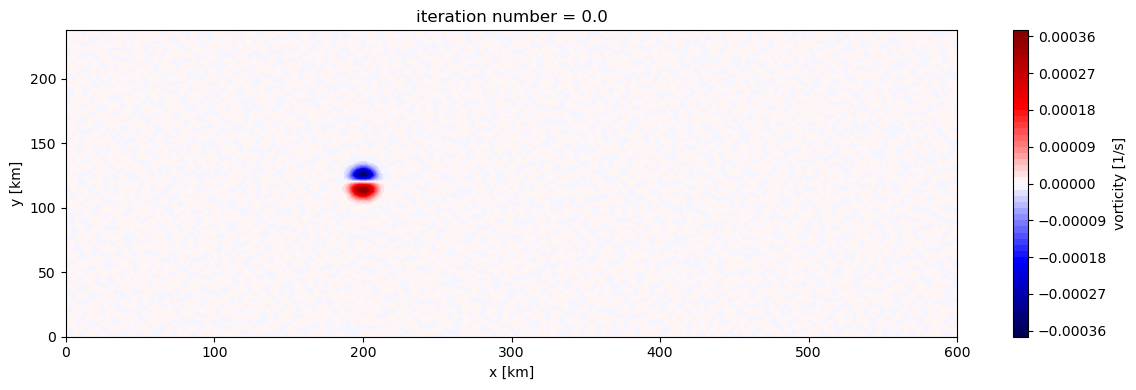

500


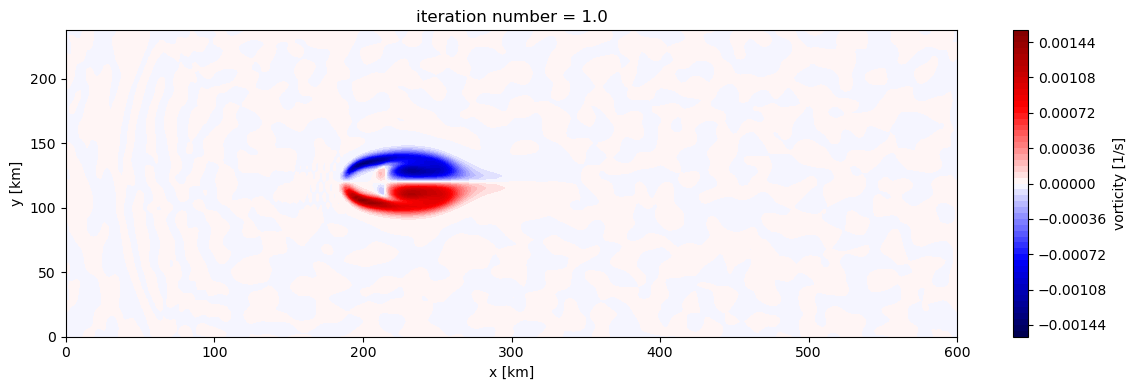

1000


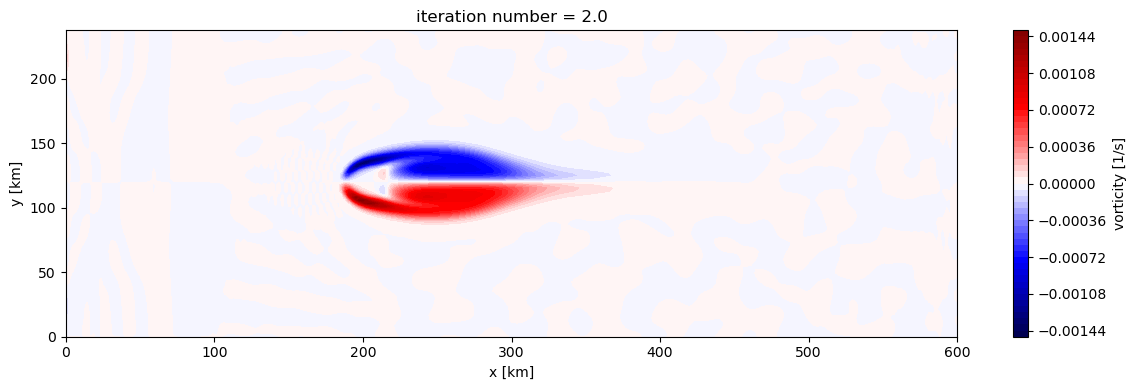

1500


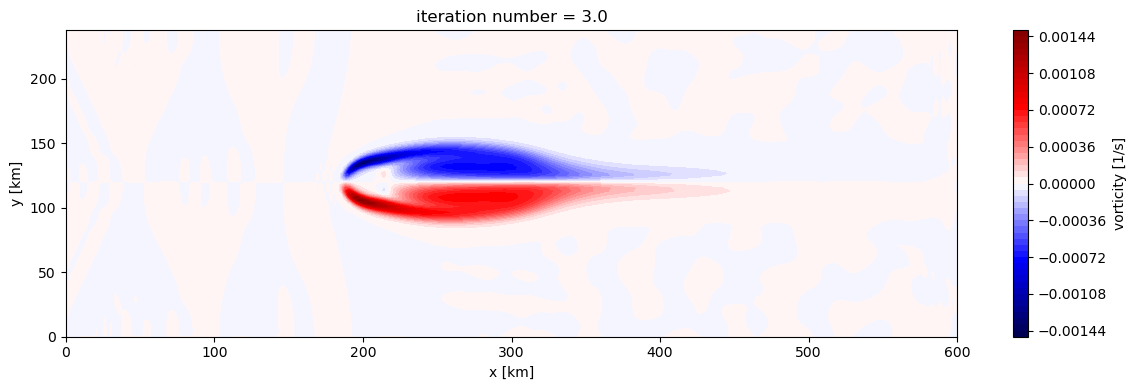

2000


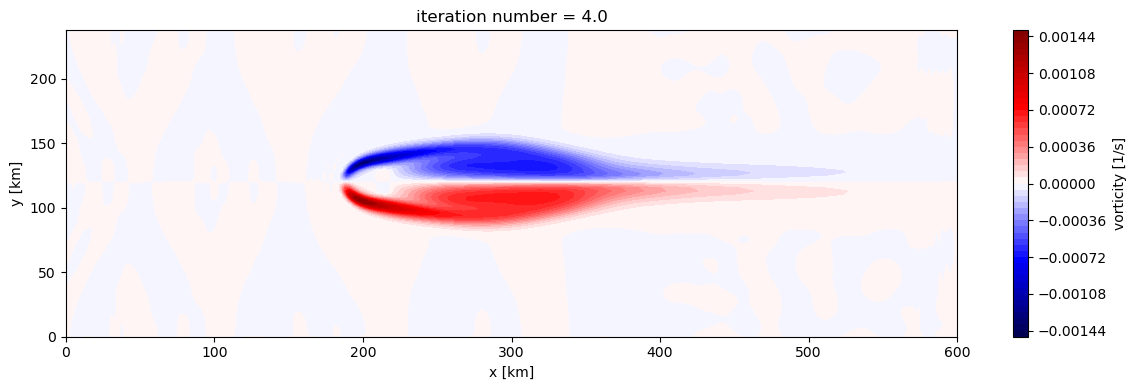

2500


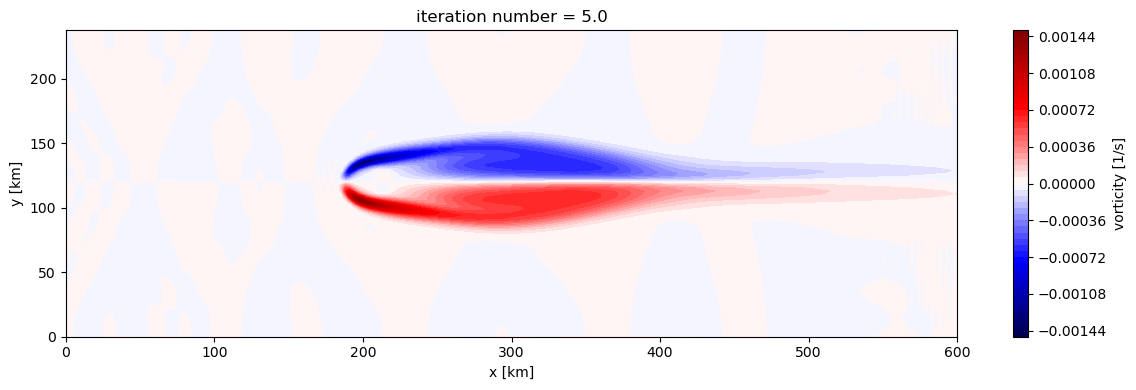

3000


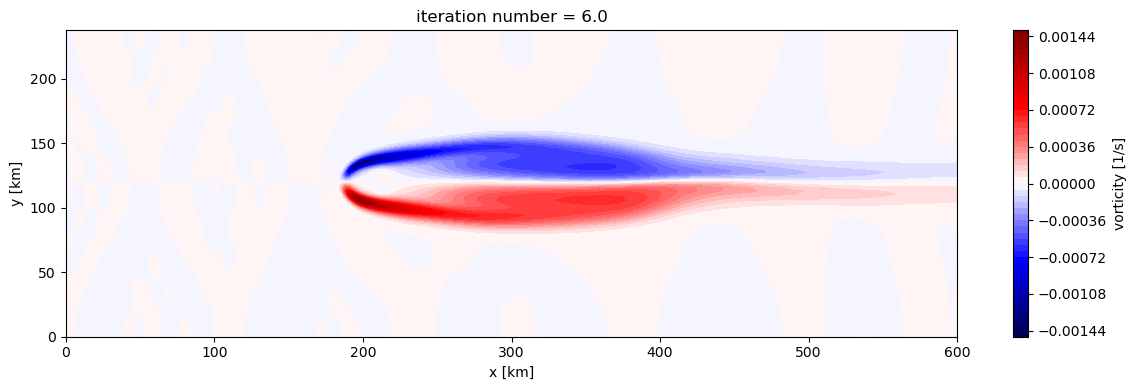

3500


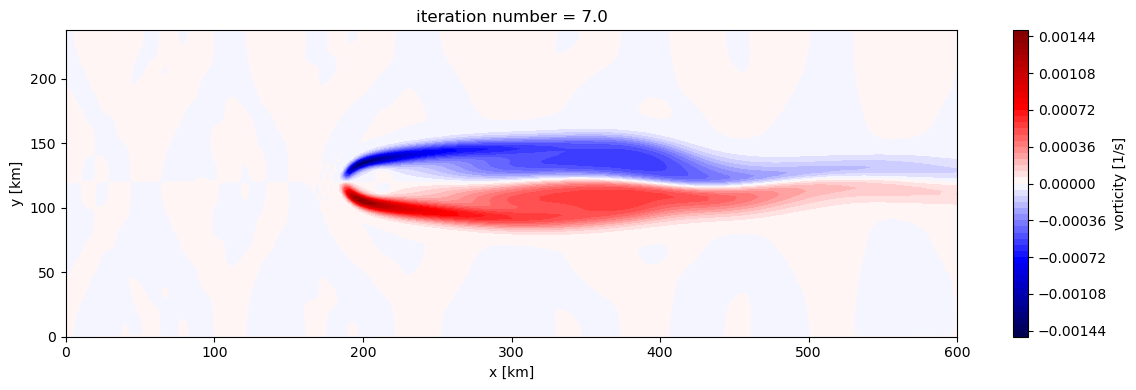

4000


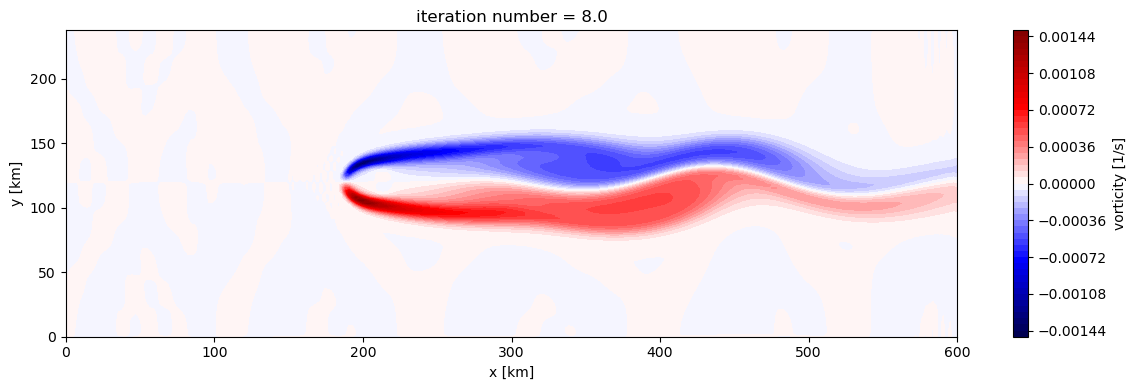

4500


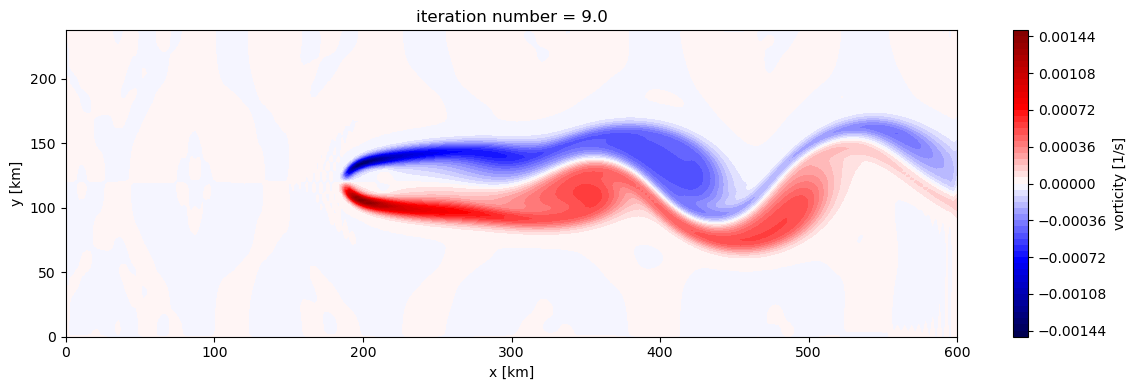

5000


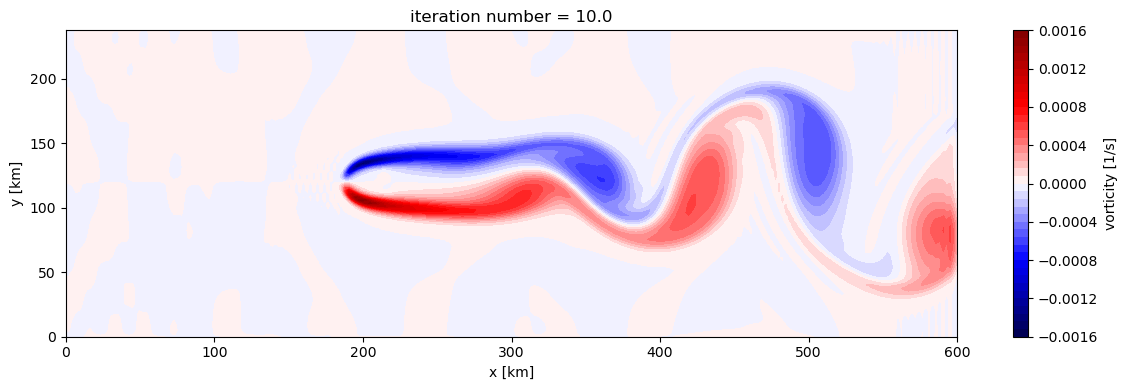

5500


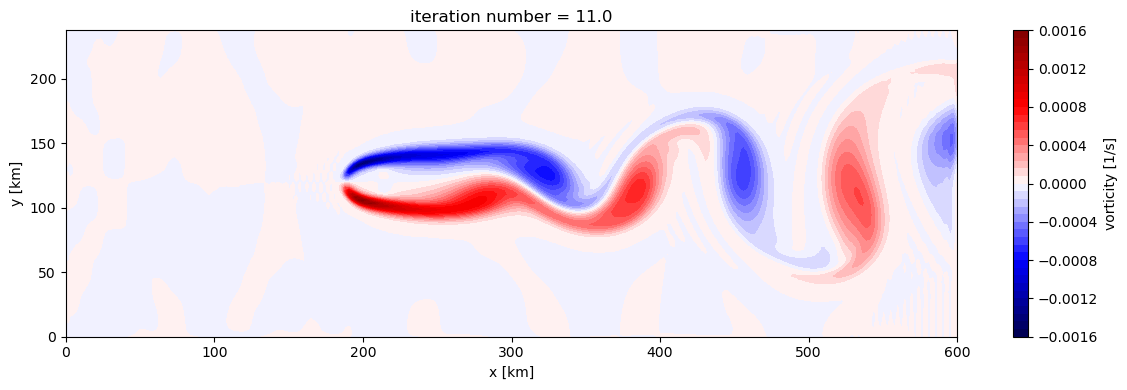

6000


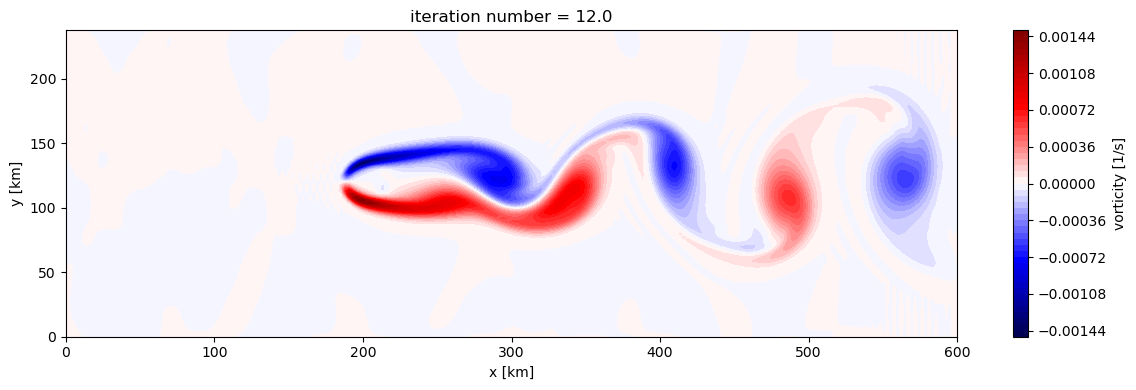

6500


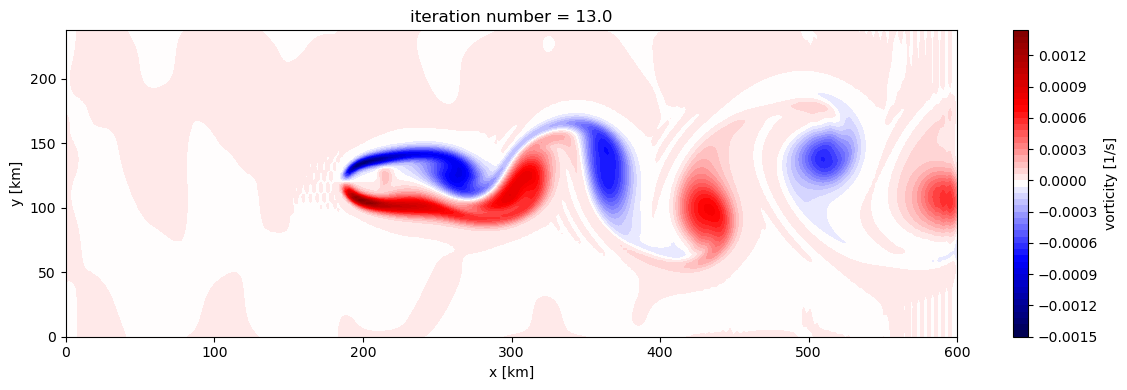

7000


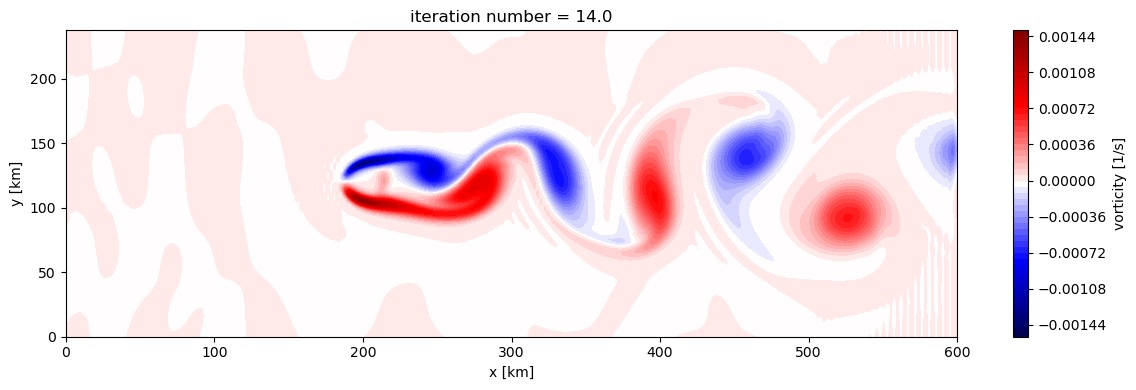

7500


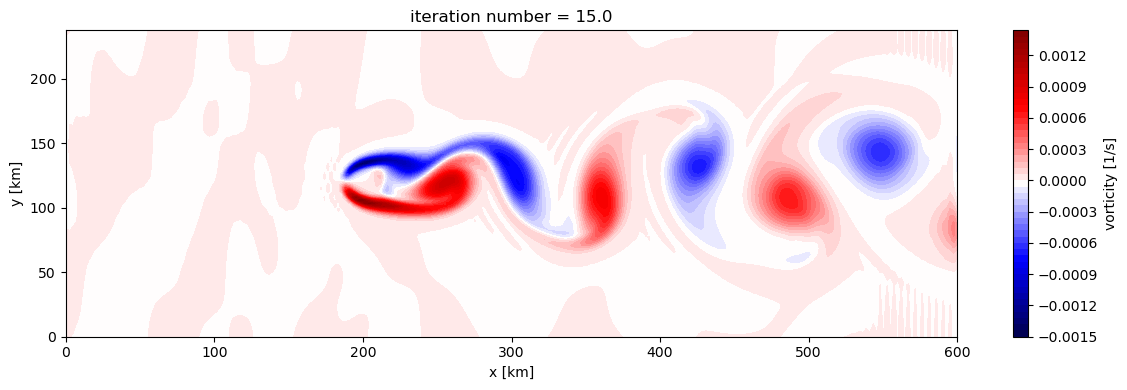

8000


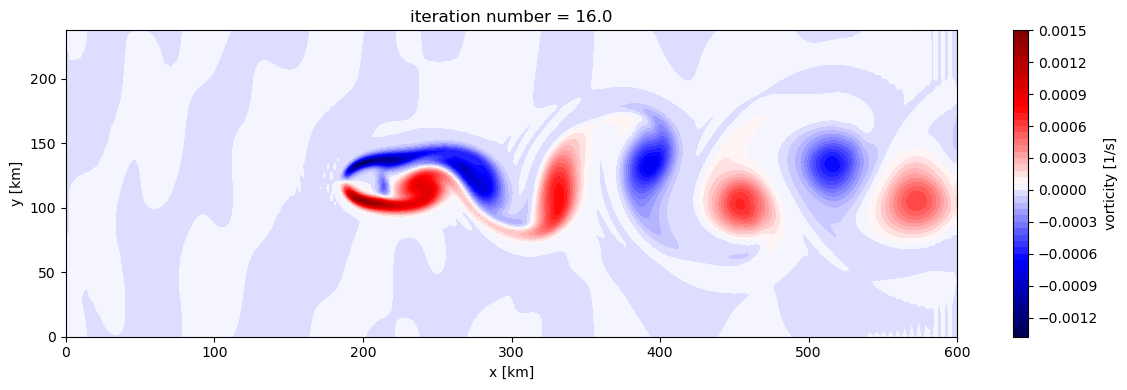

8500


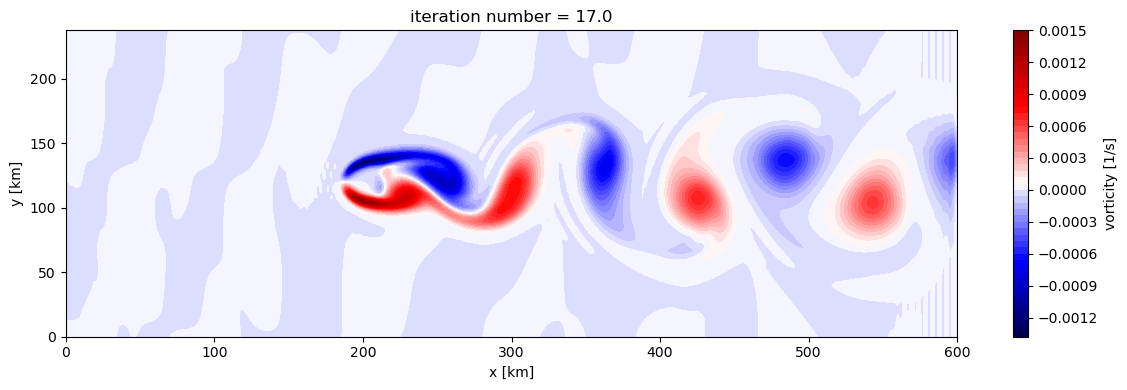

9000


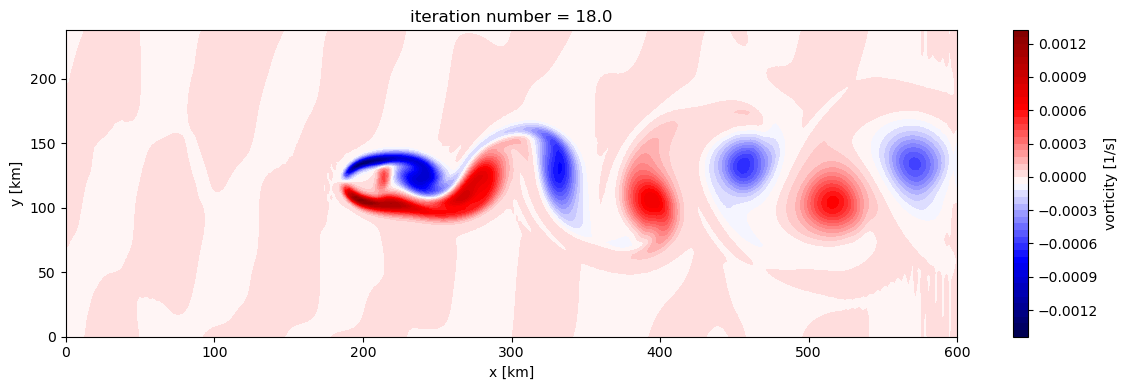

9500


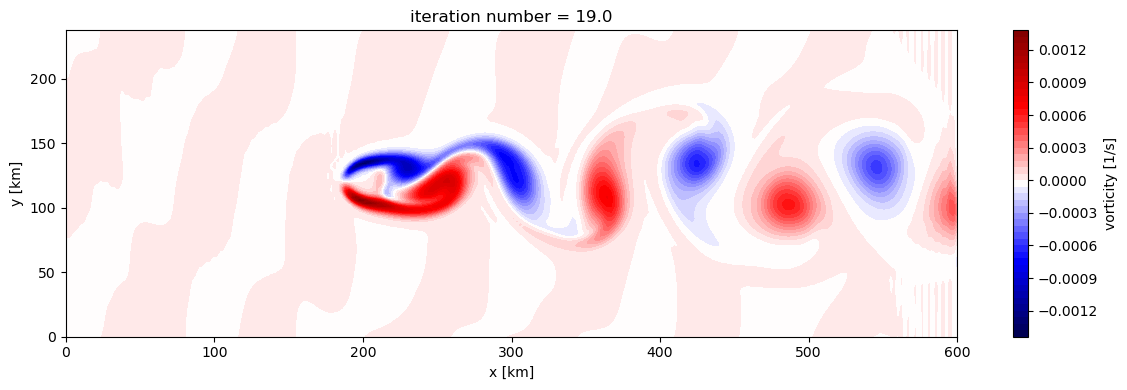

10000


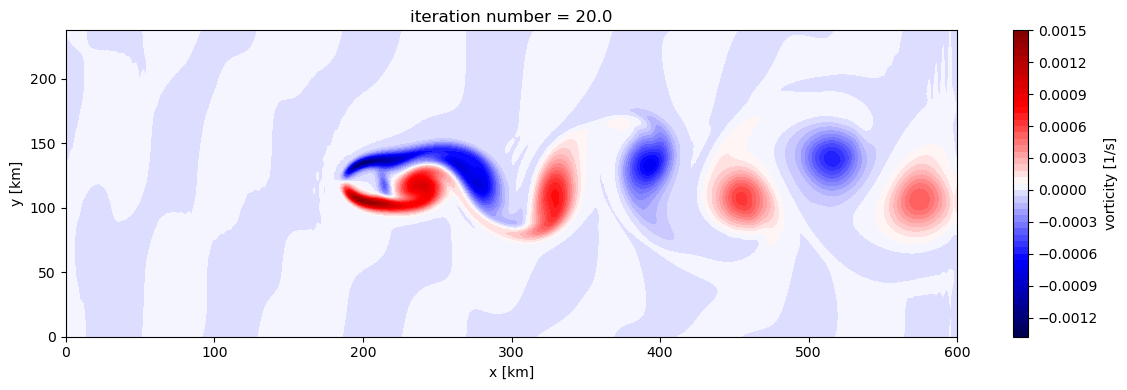

10500


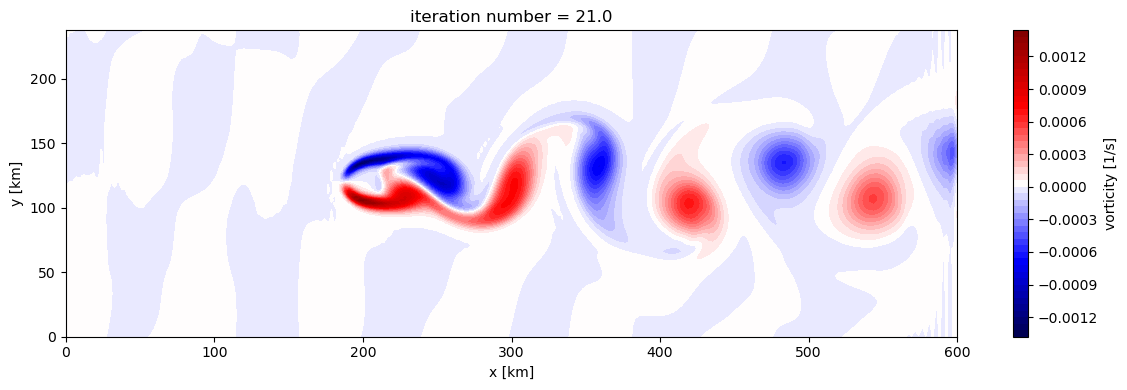

11000


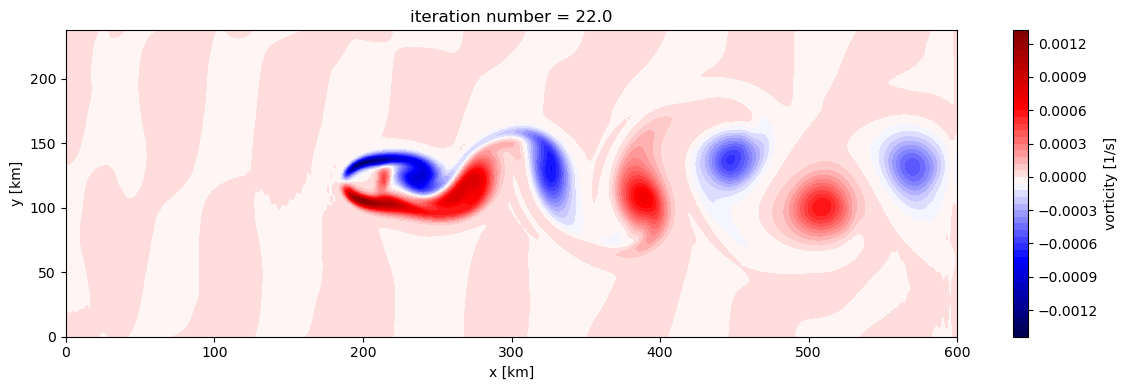

11500


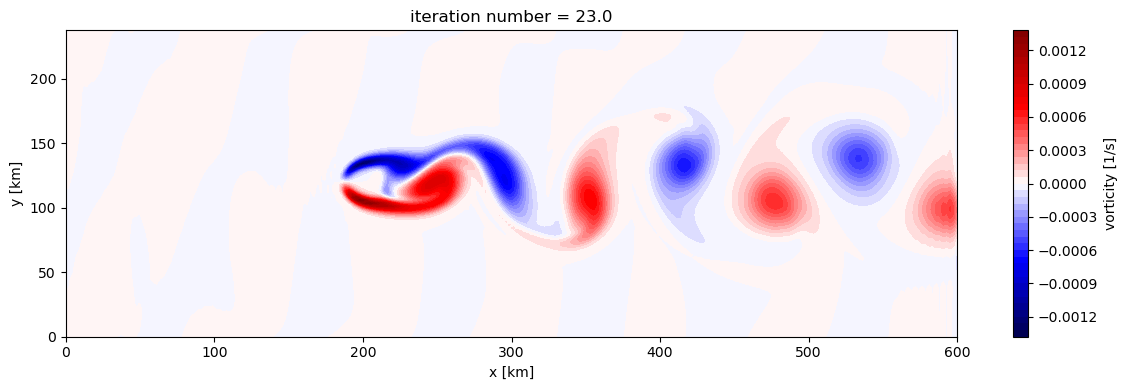

12000


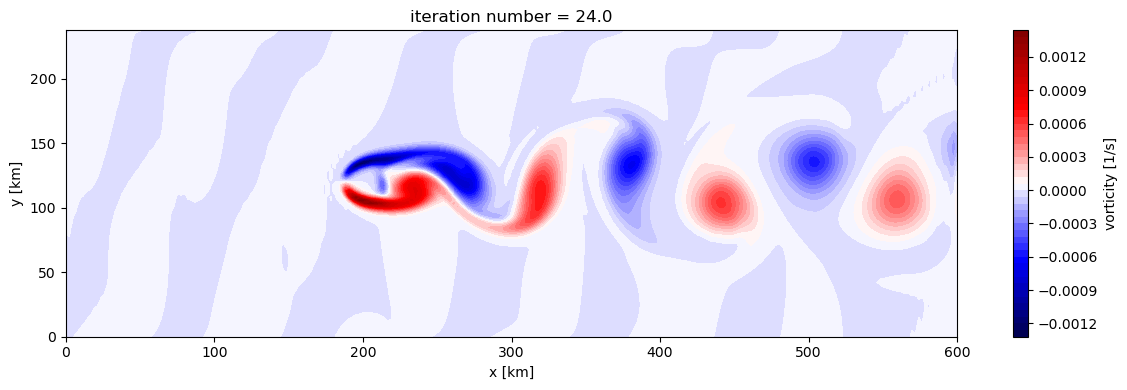

12500


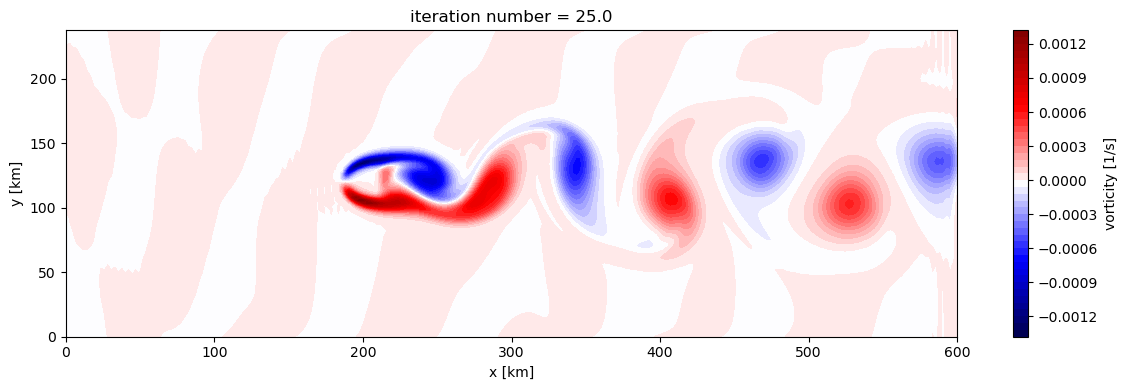

13000


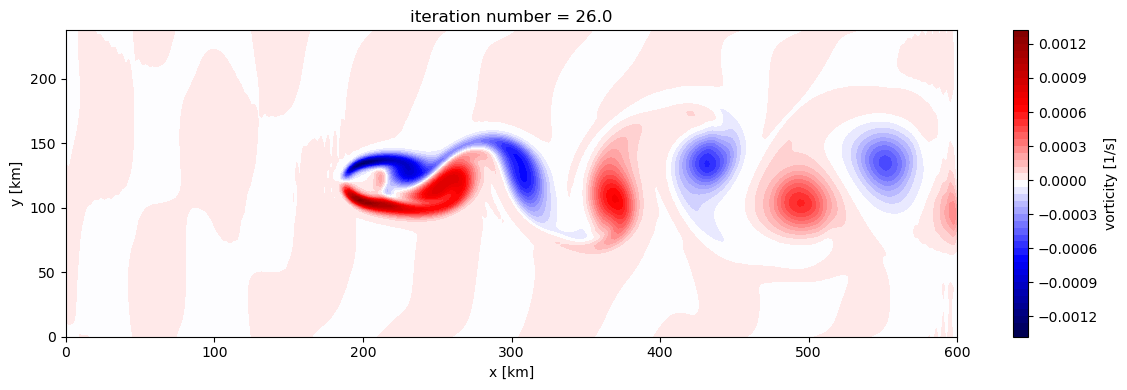

13500


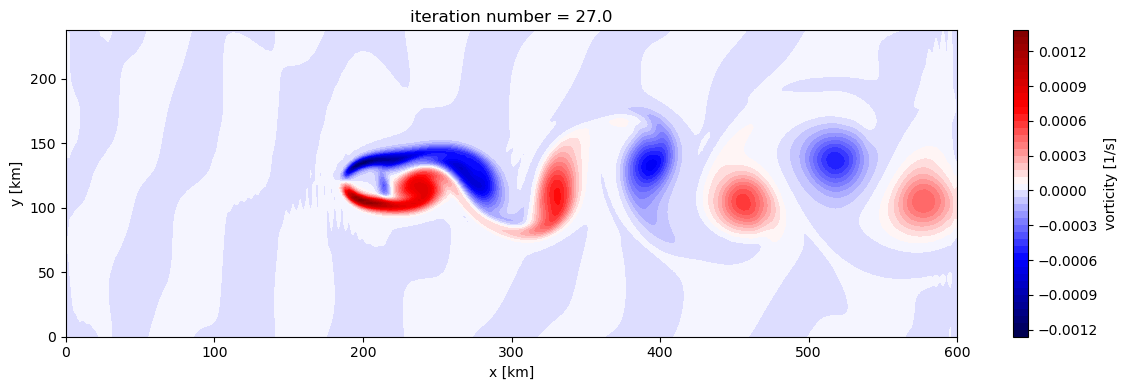

14000


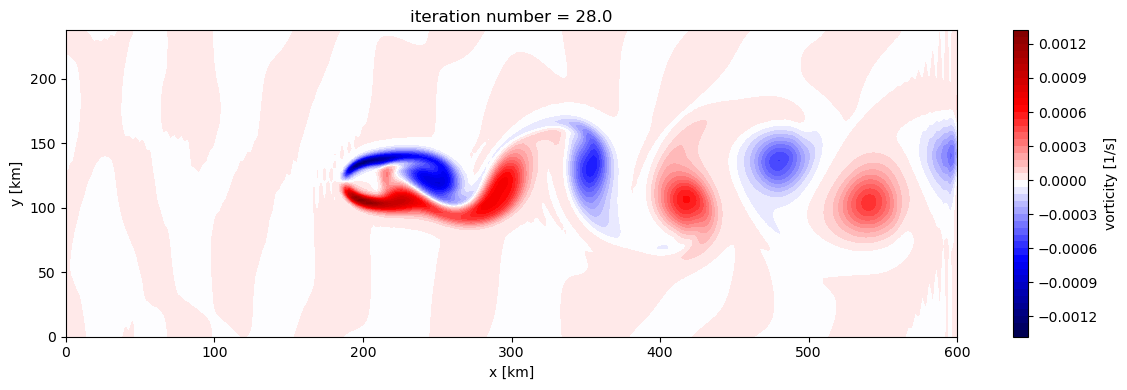

14500


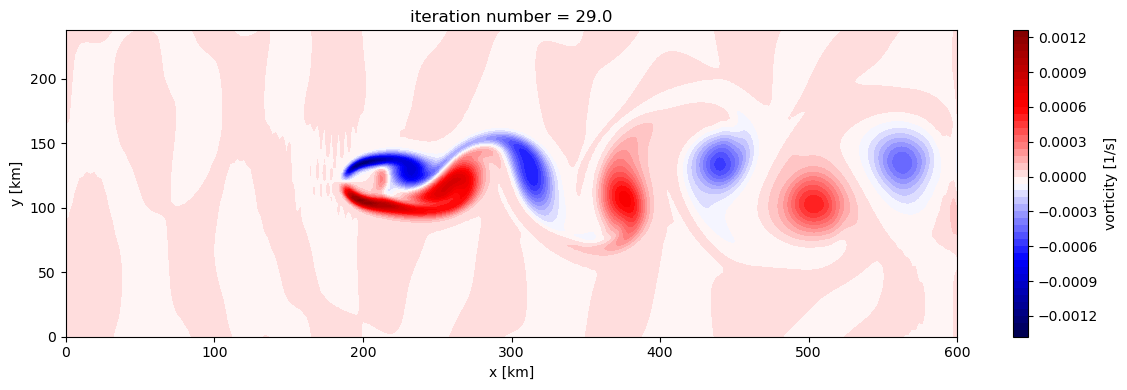

15000


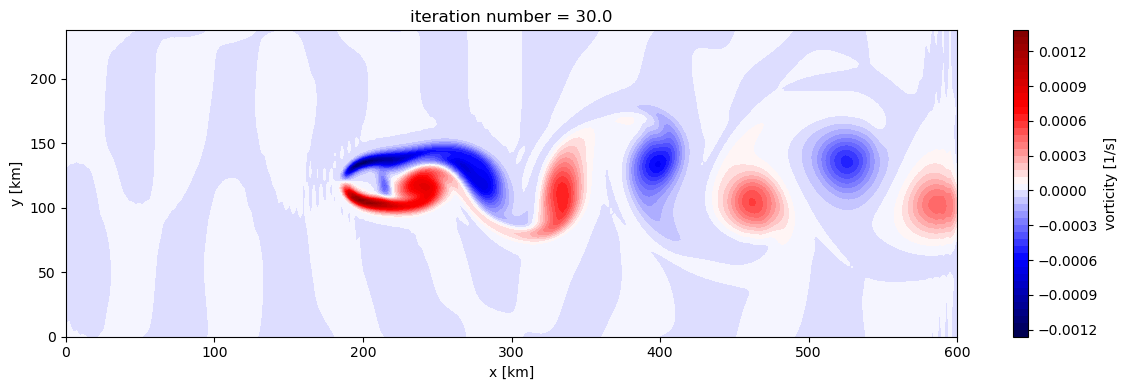

15500


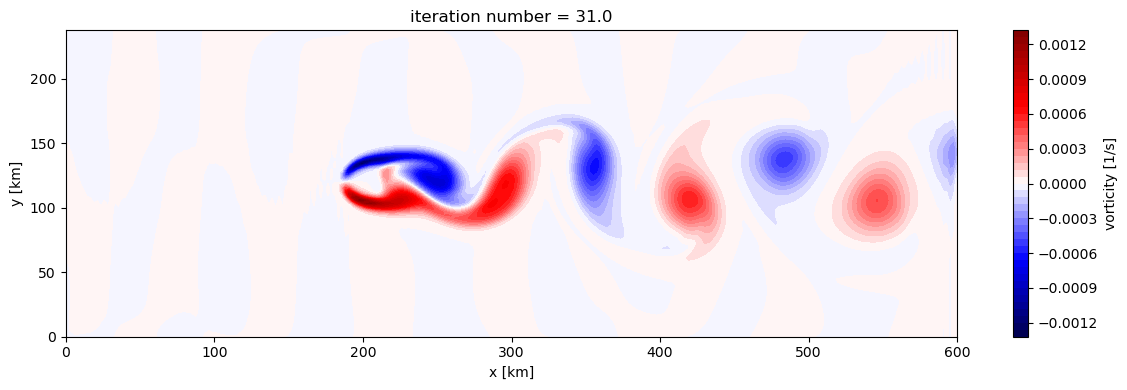

16000


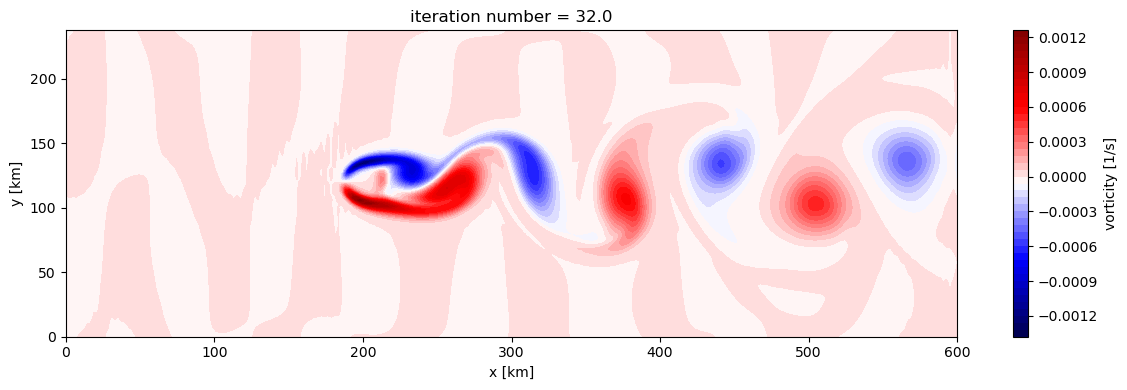

16500


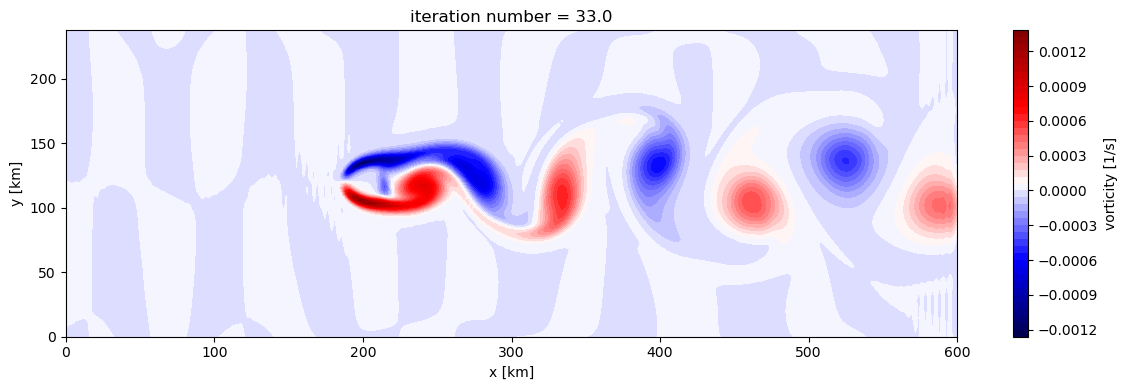

17000


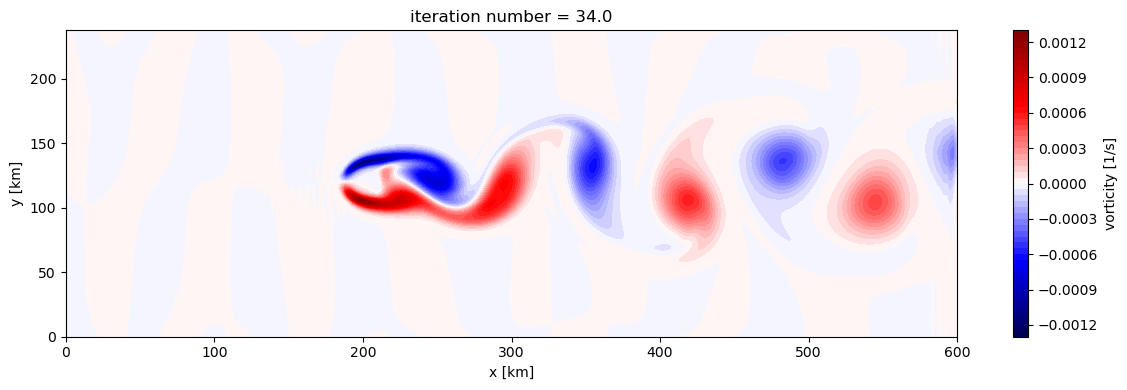

17500


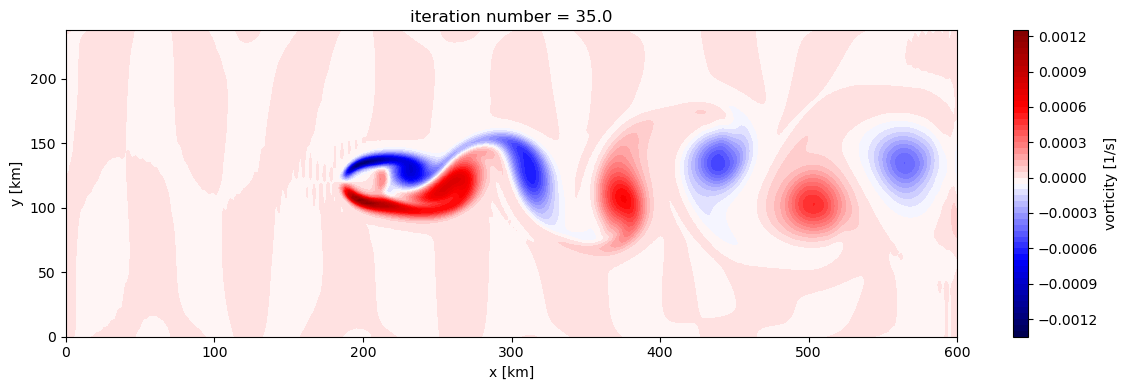

18000


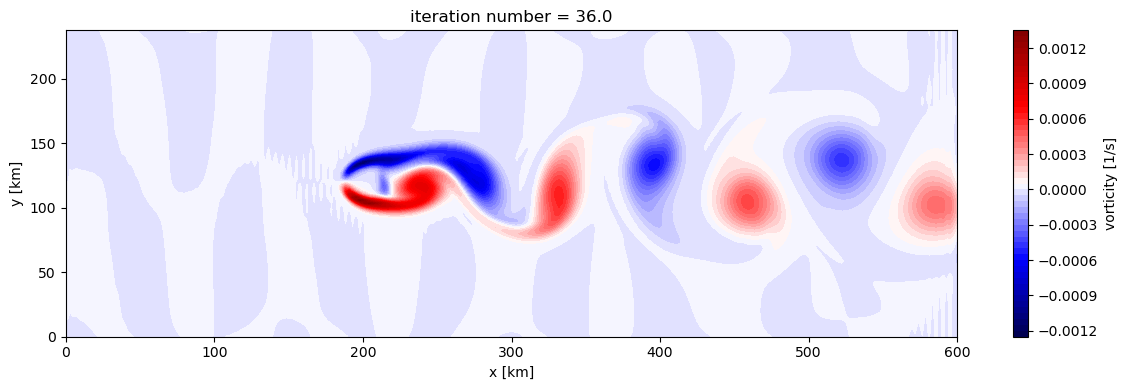

18500


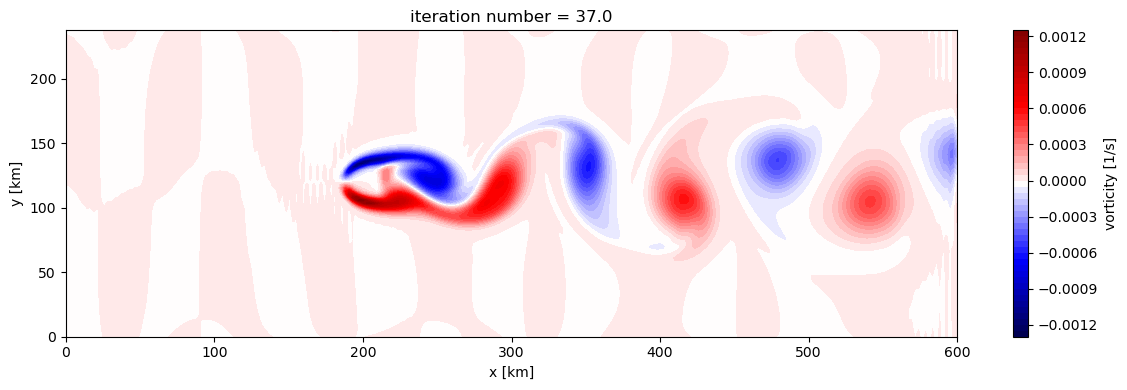

19000


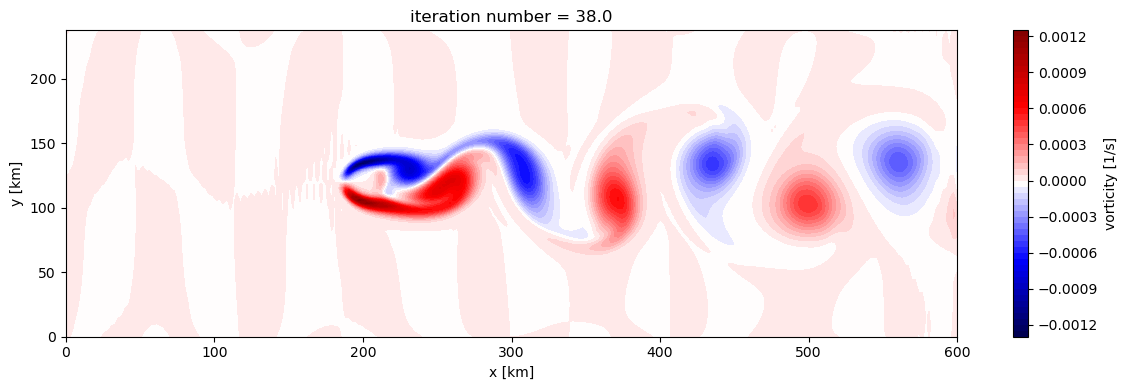

19500


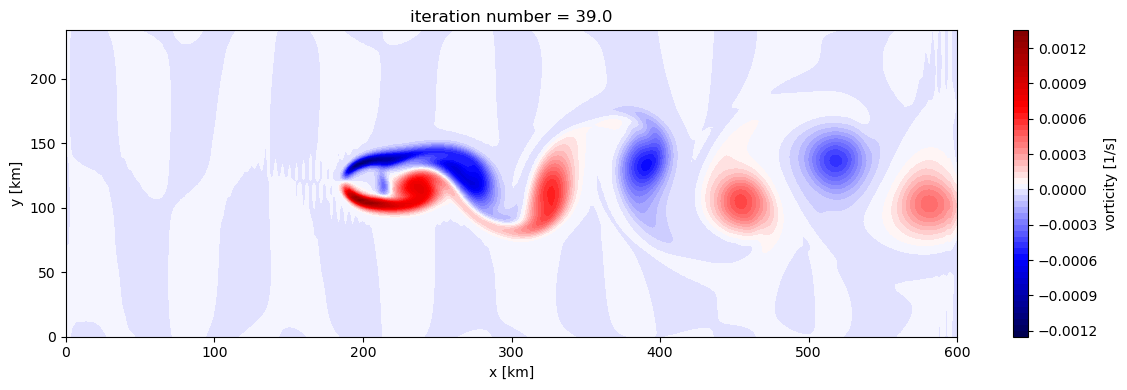

20000


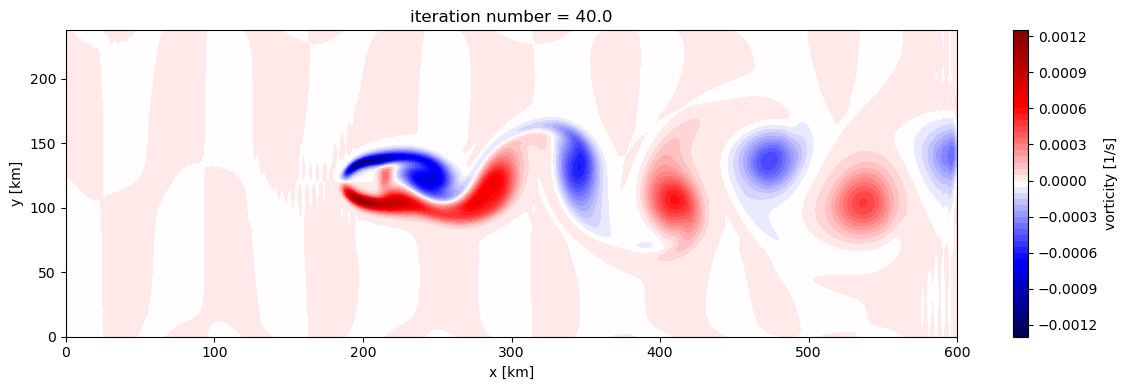

20500


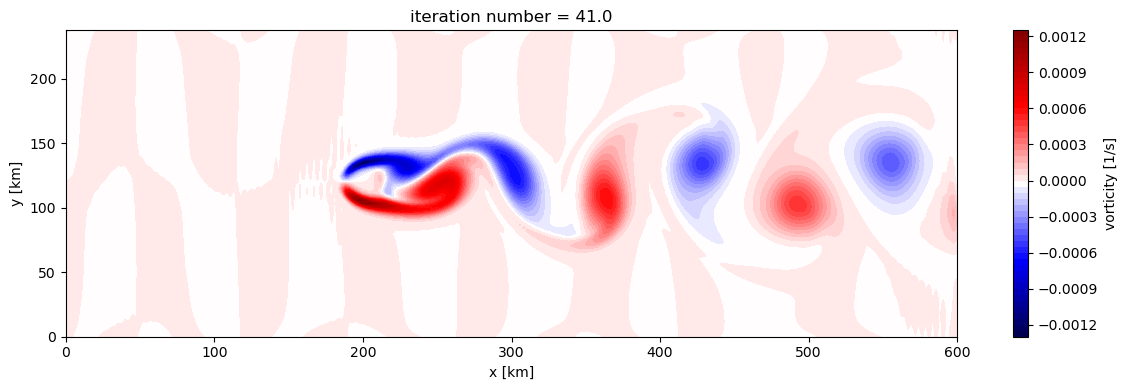

21000


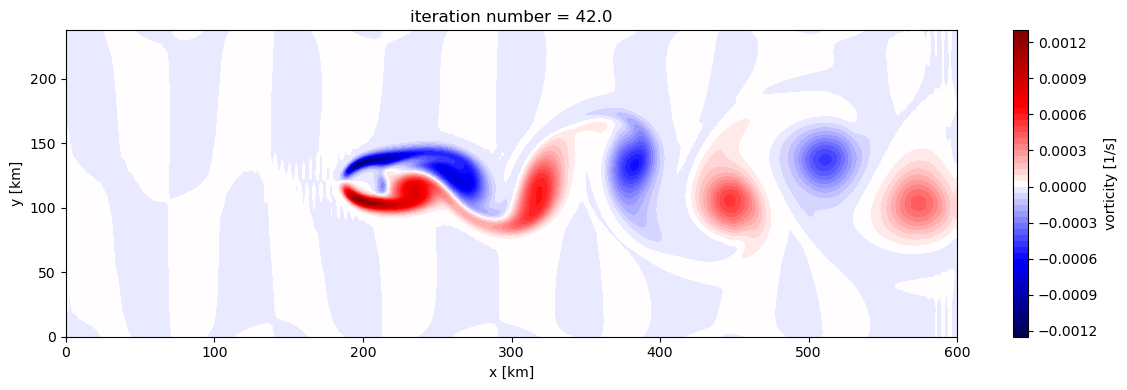

21500


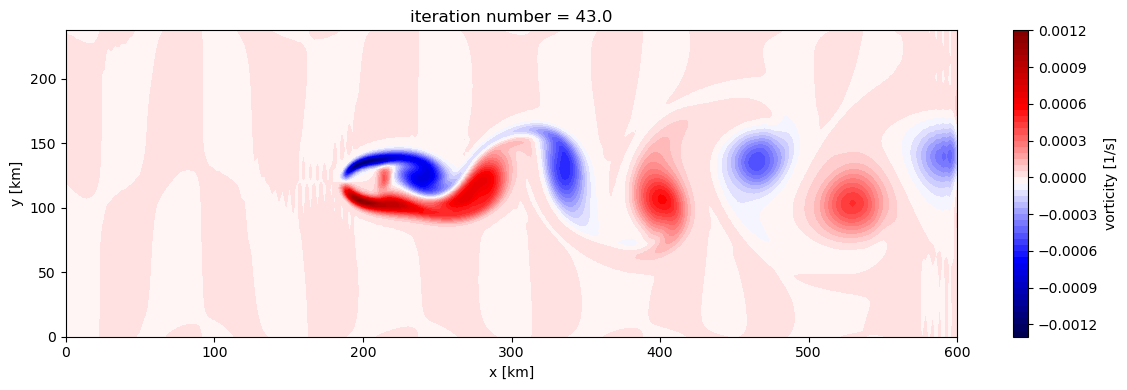

22000


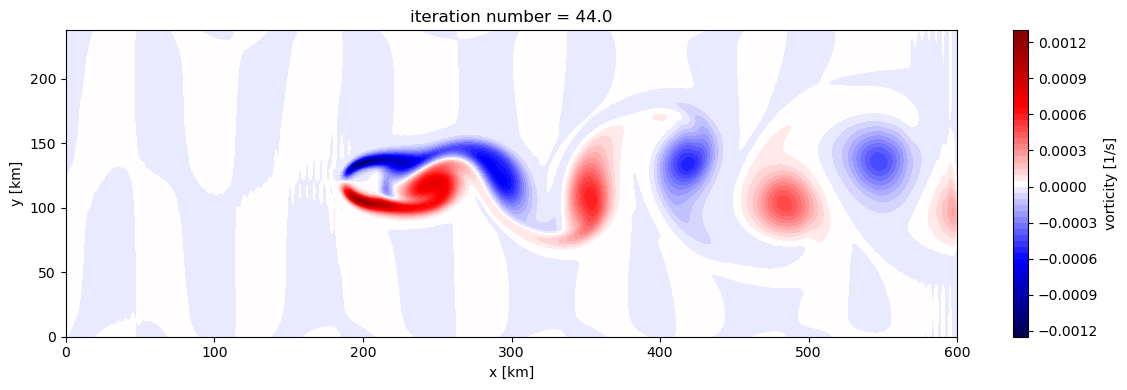

22500


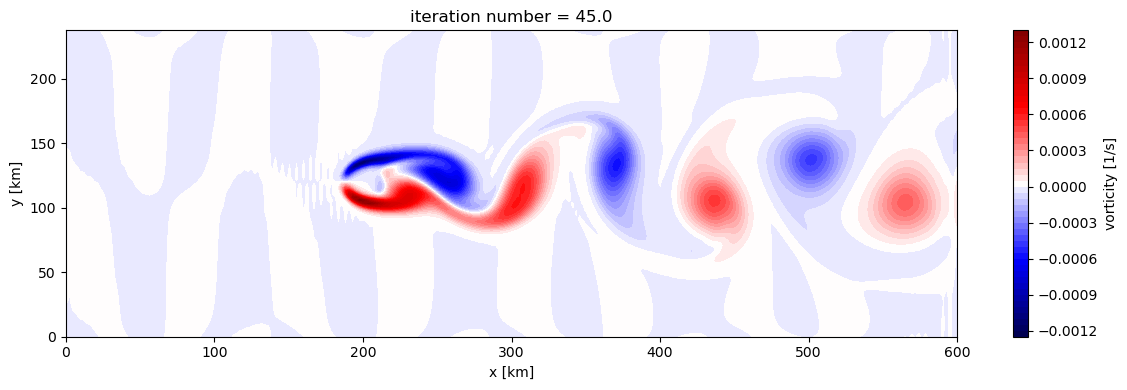

23000


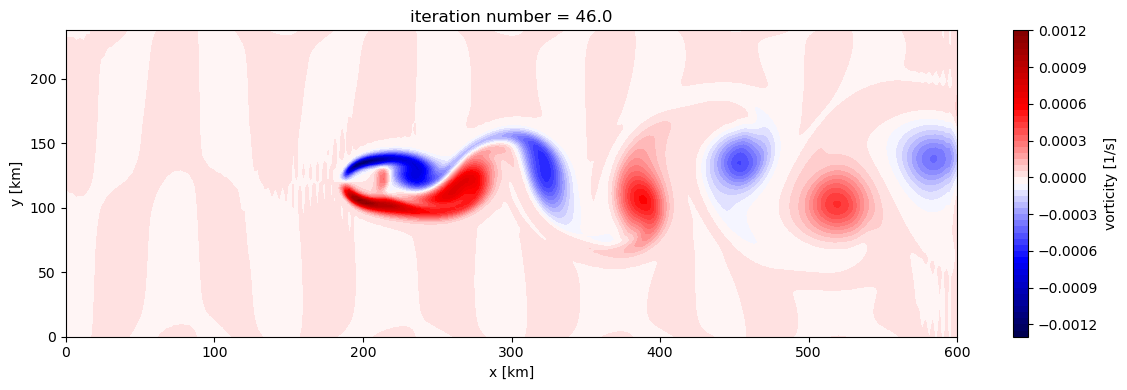

23500


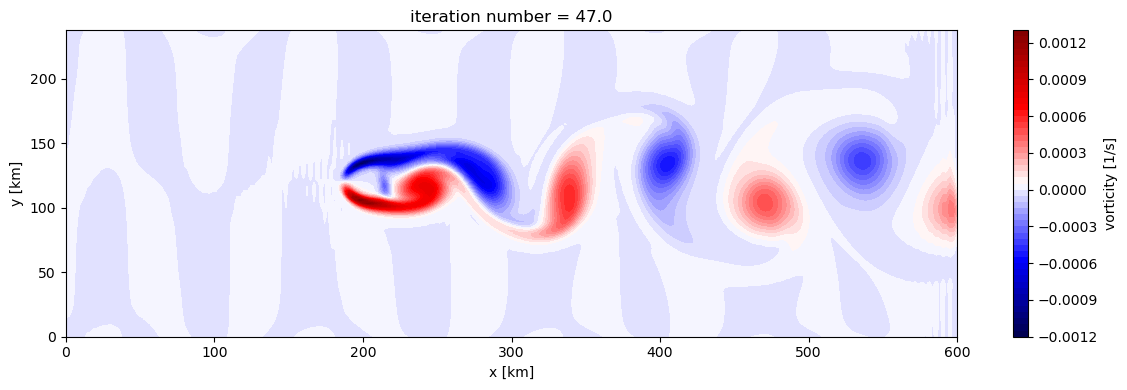

24000


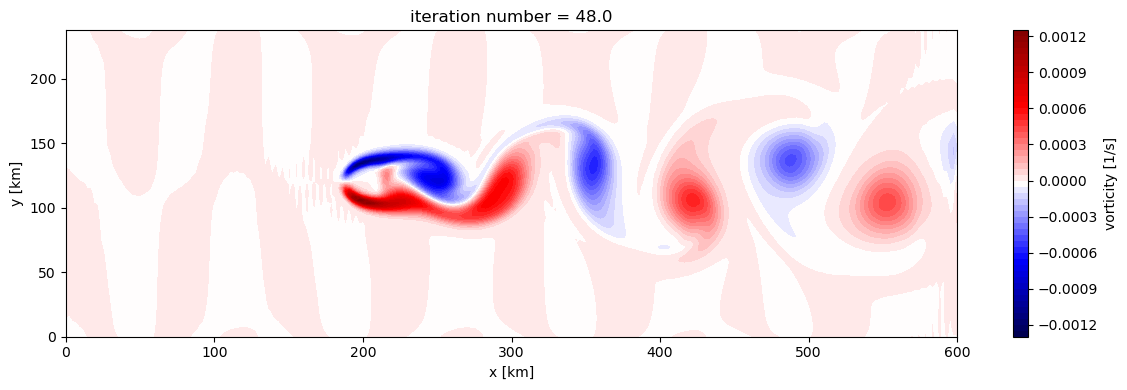

24500


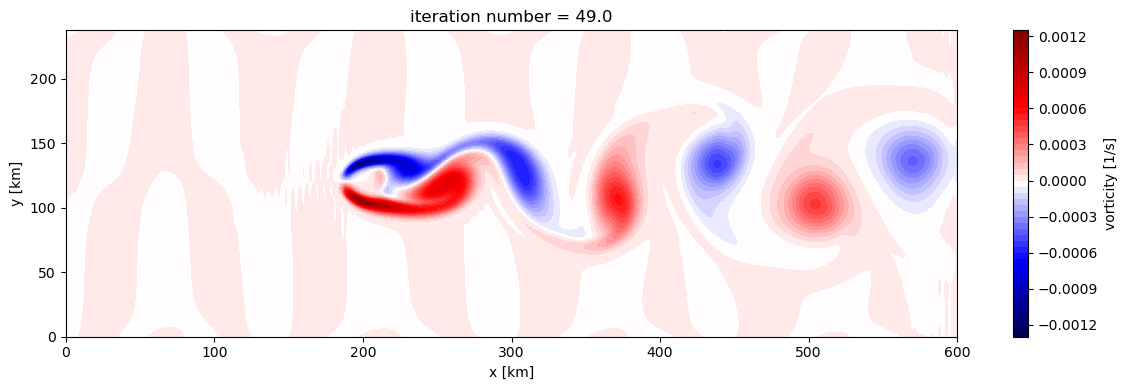

25000


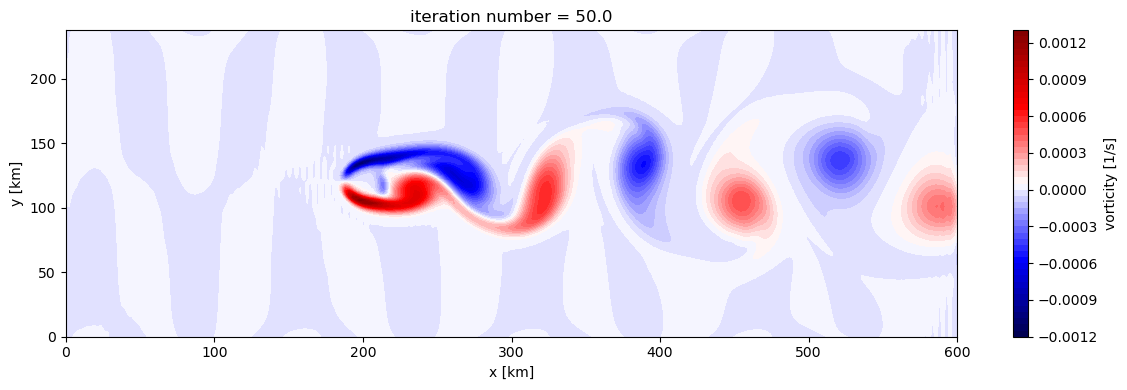

25500


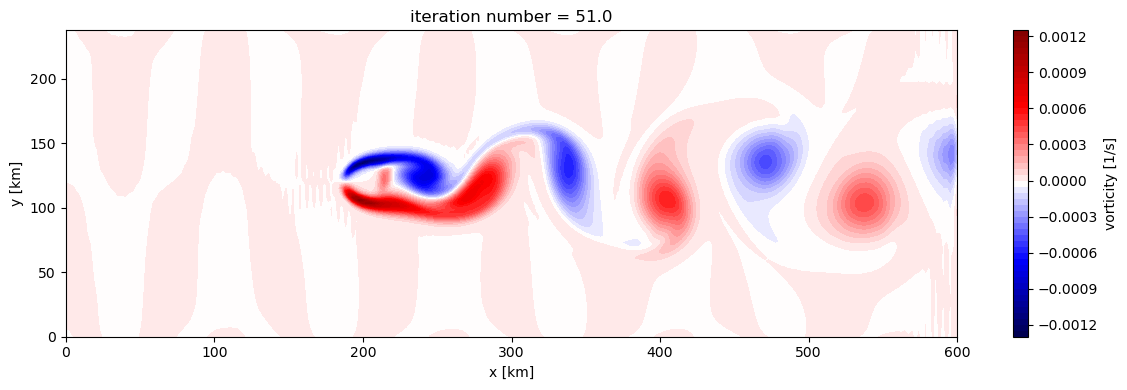

26000


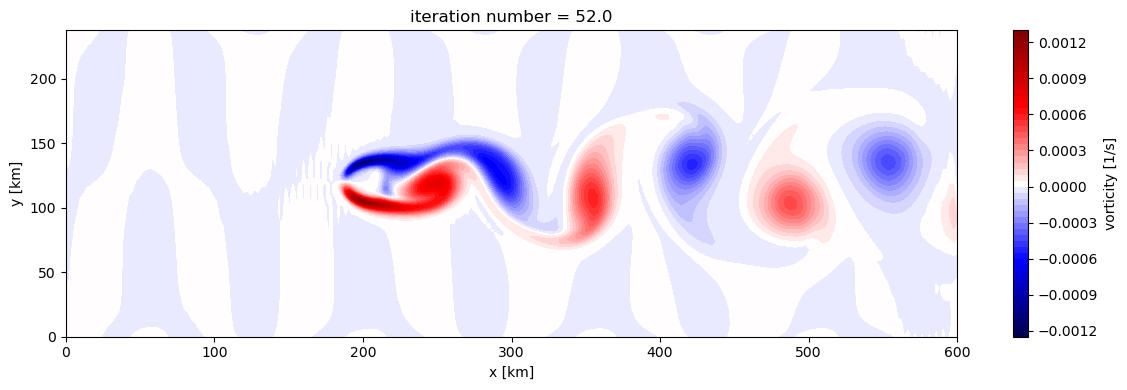

26500


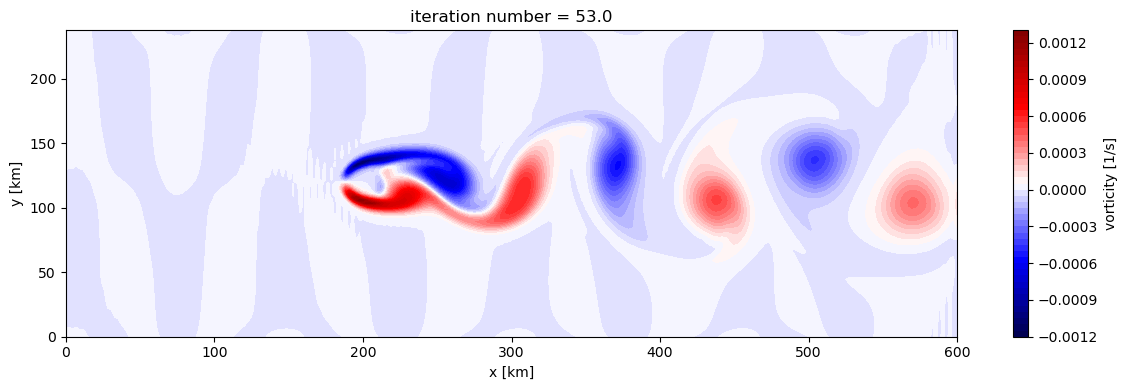

27000


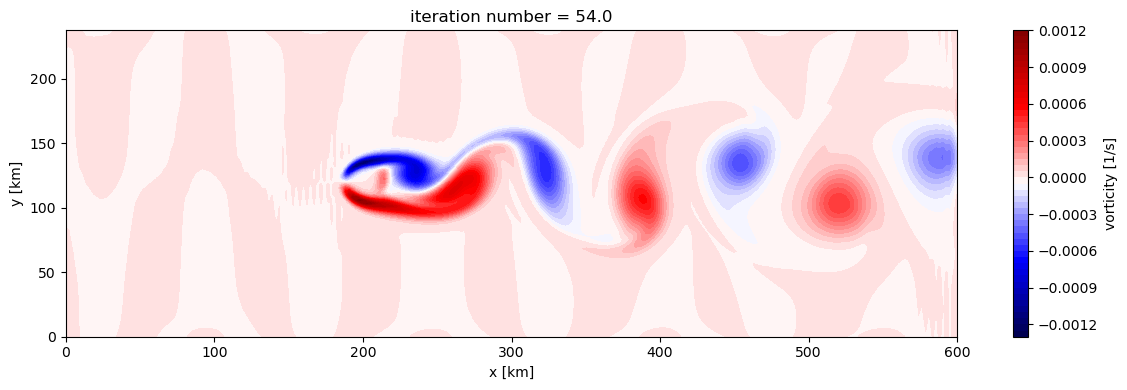

27500


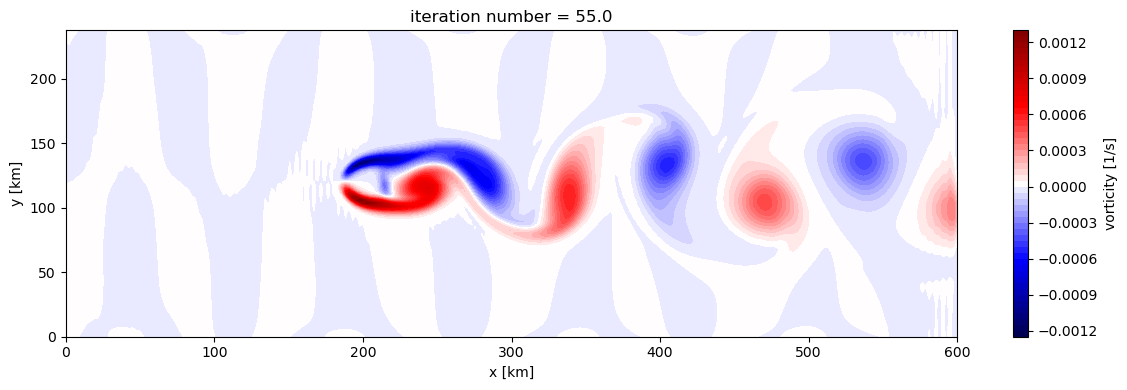

28000


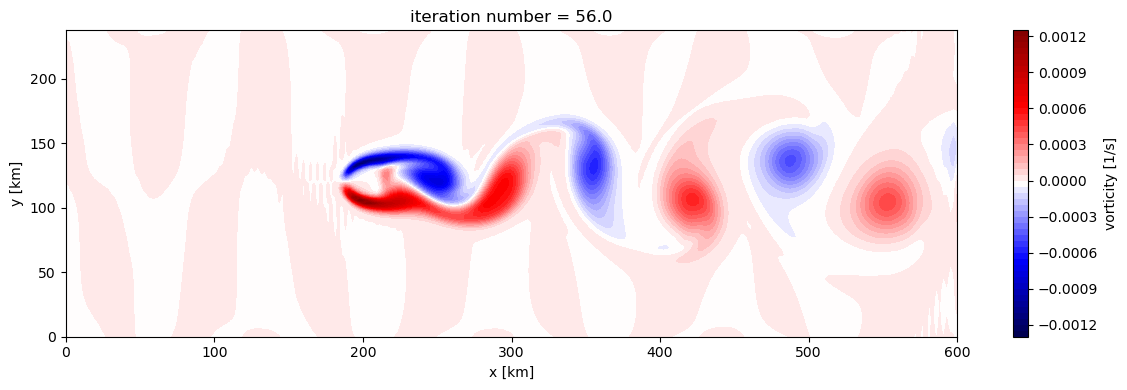

28500


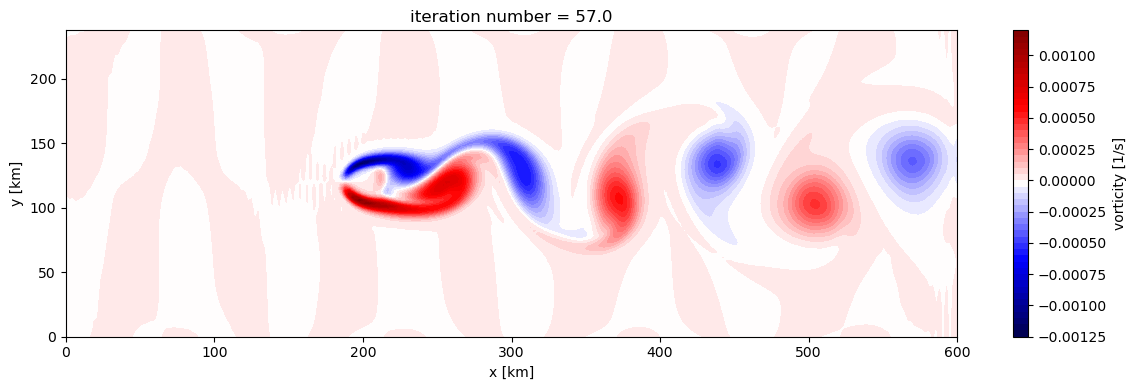

29000


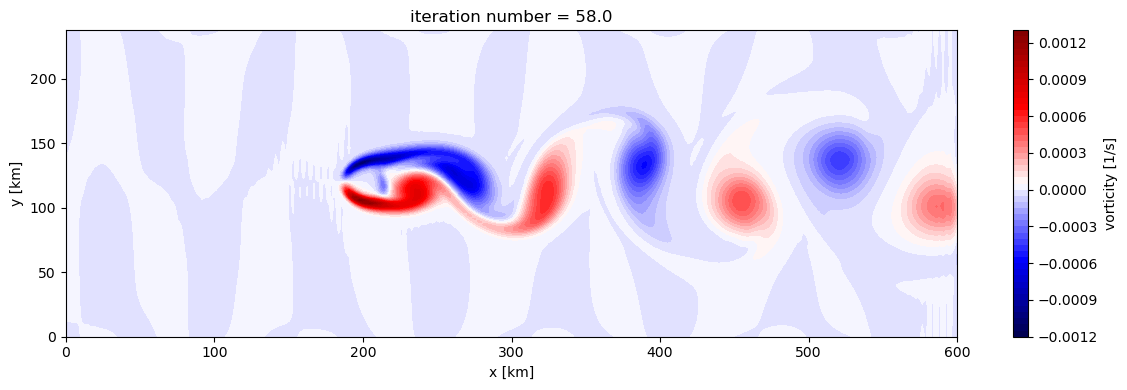

29500


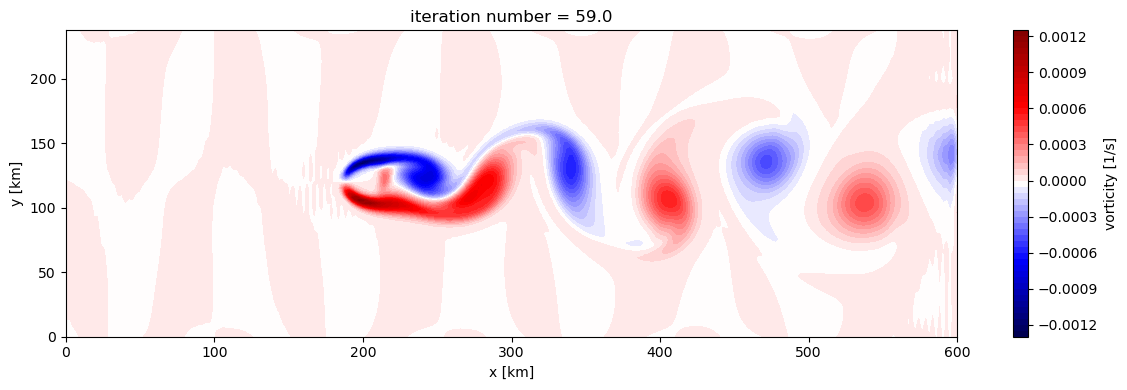

30000


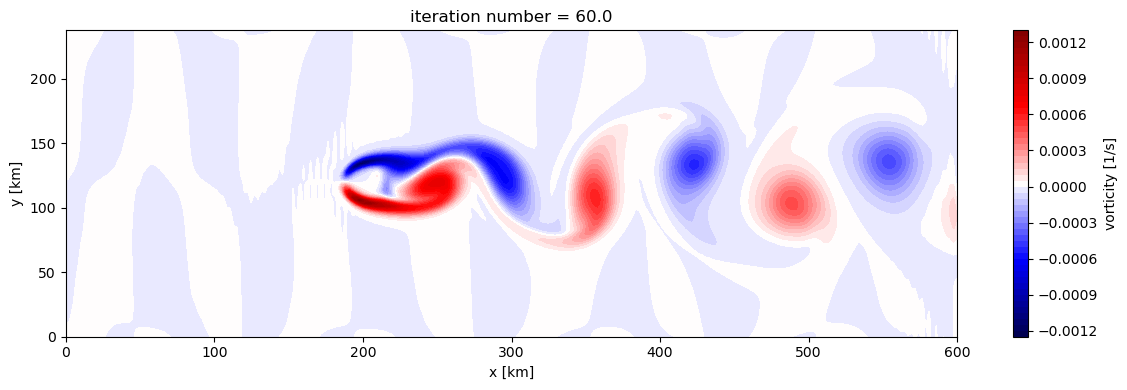

30500


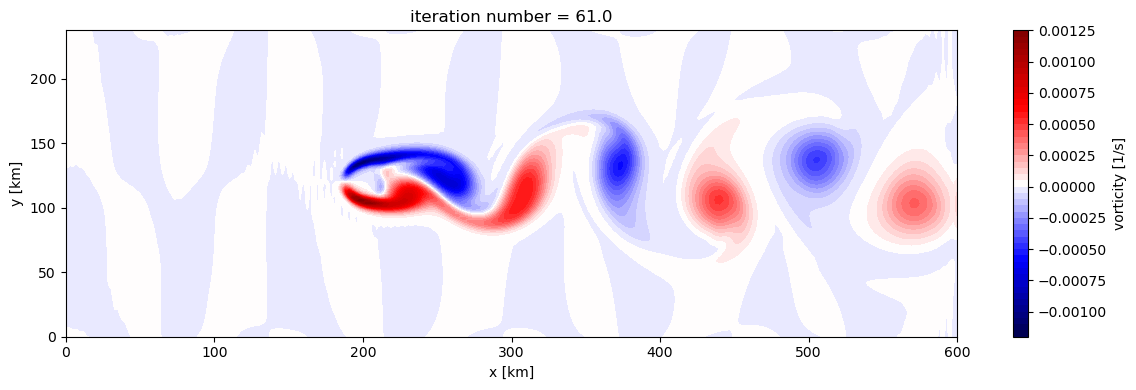

31000


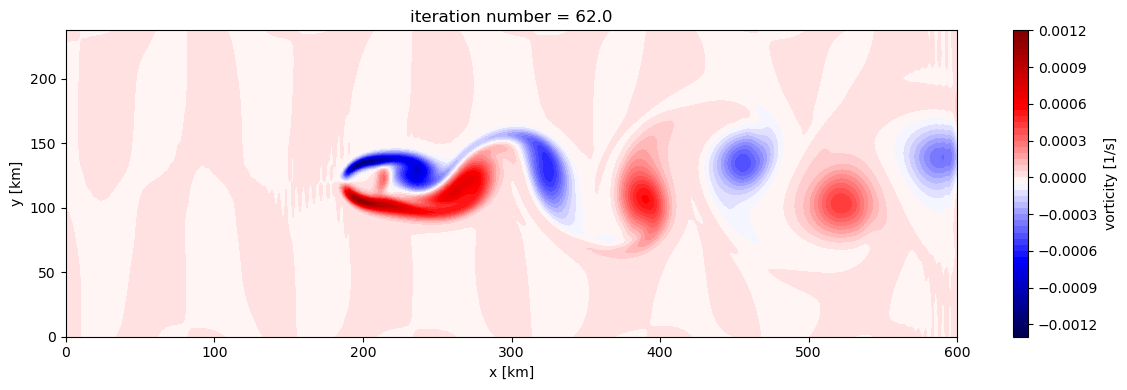

31500


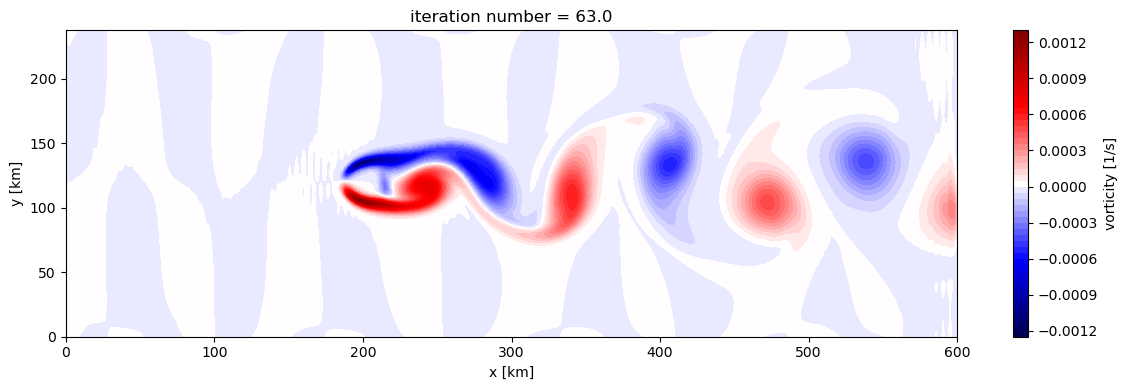

32000


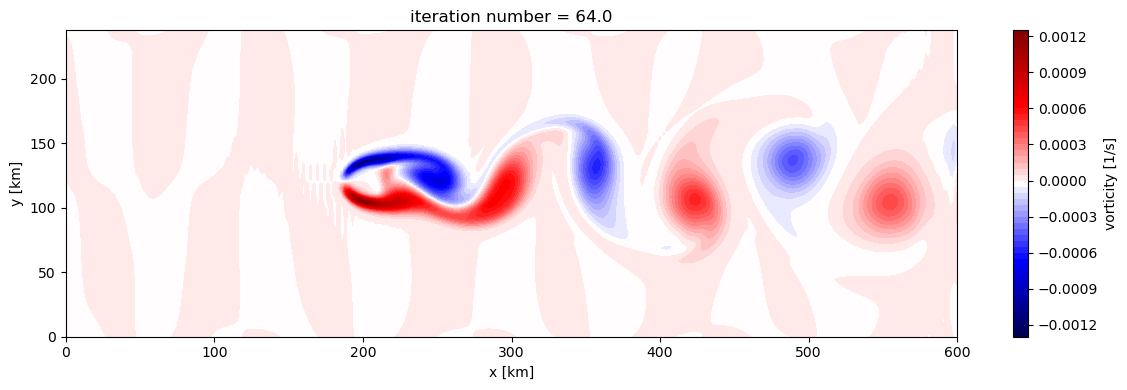

32500


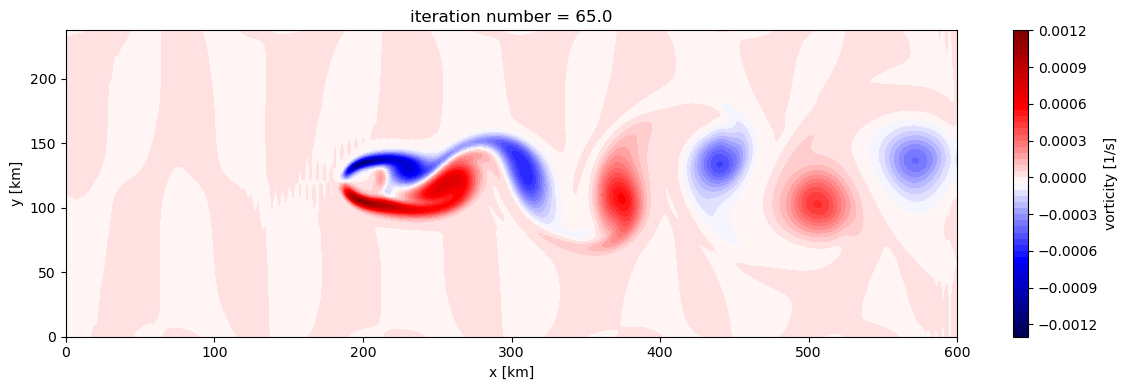

33000


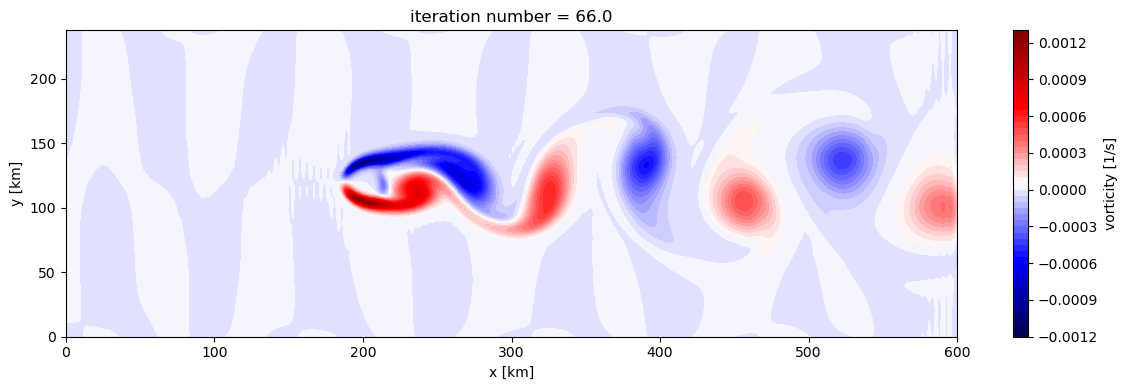

33500


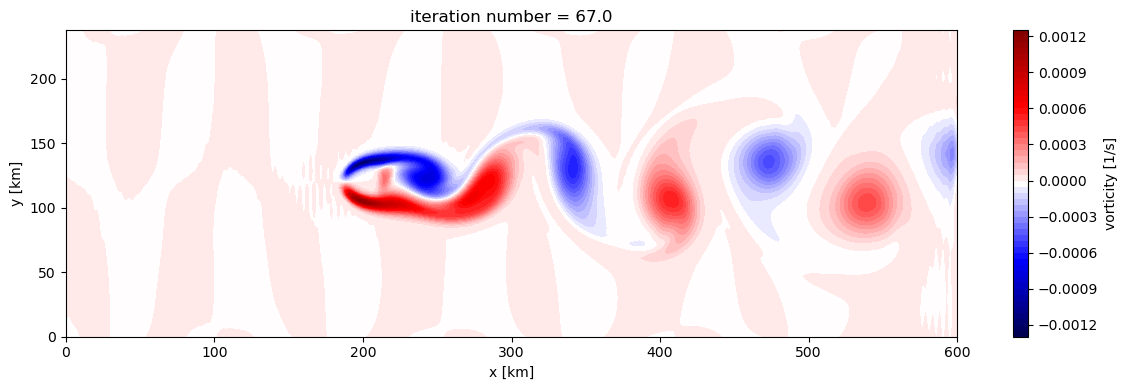

34000


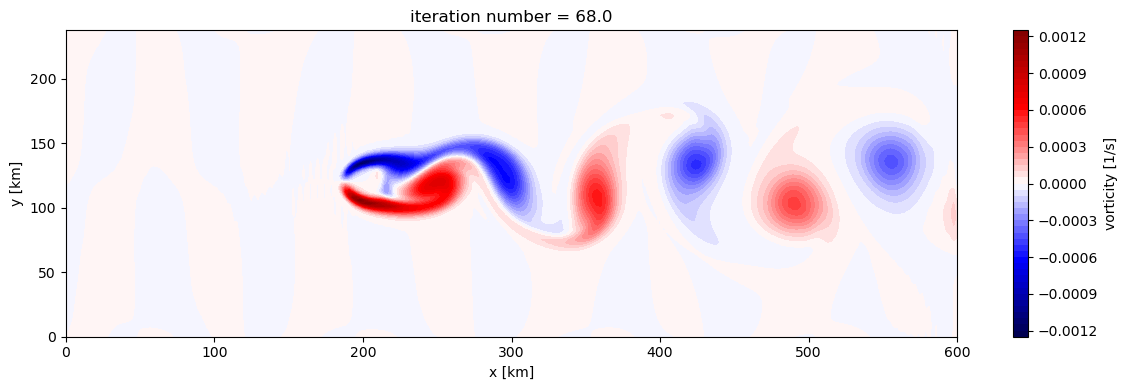

34500


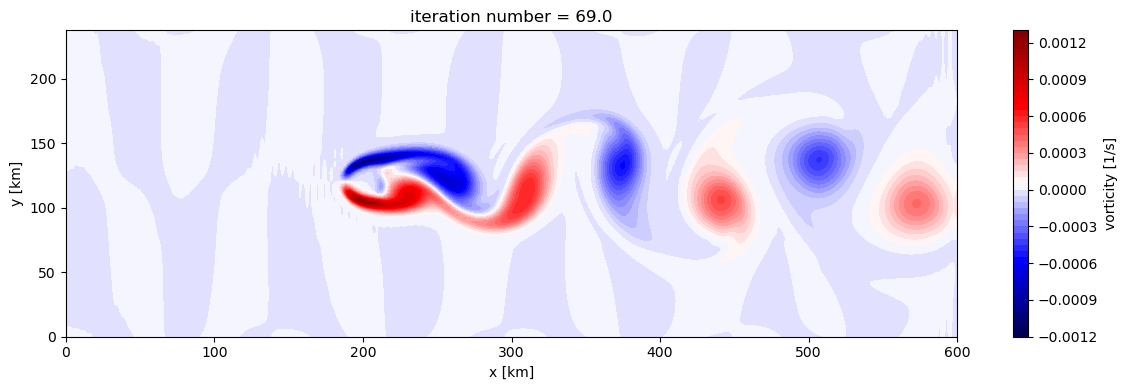

35000


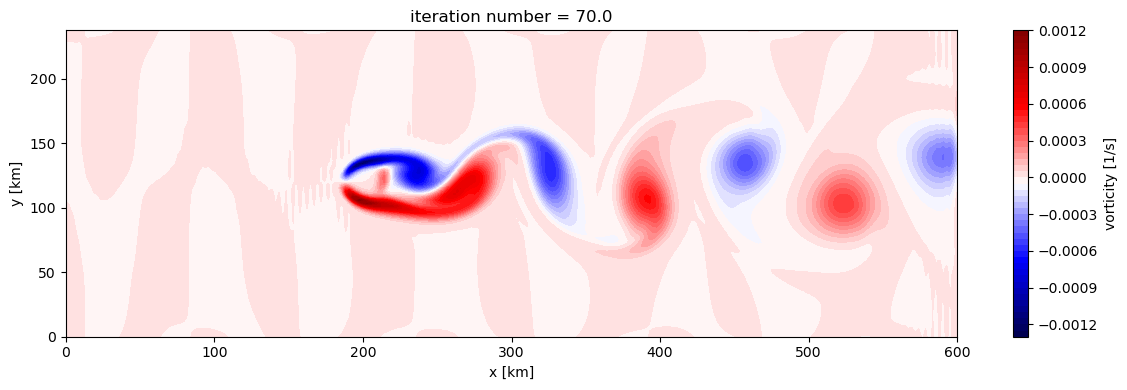

35500


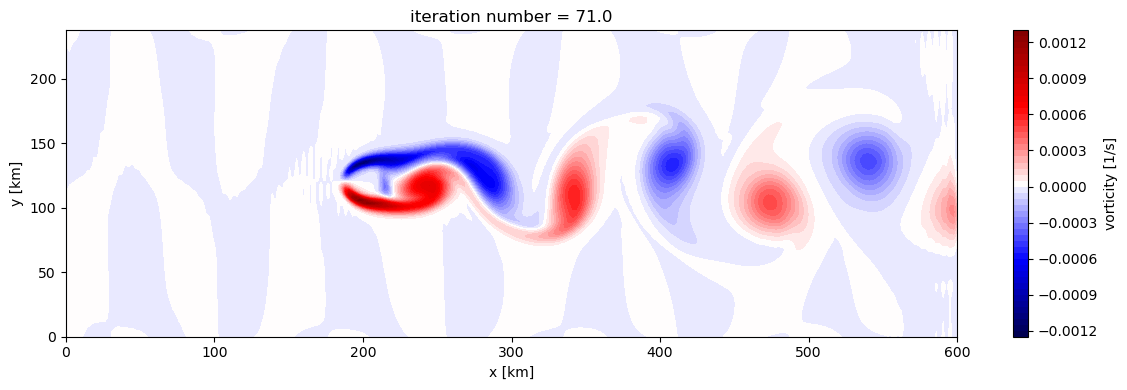

36000


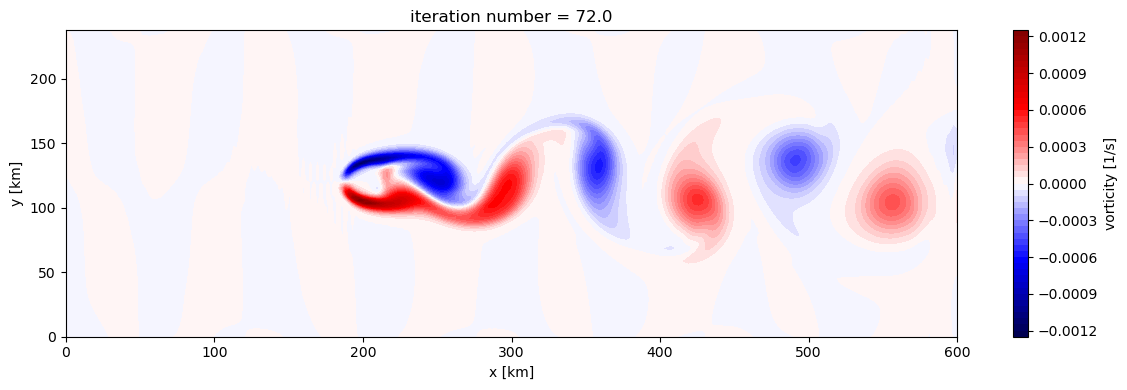

36500


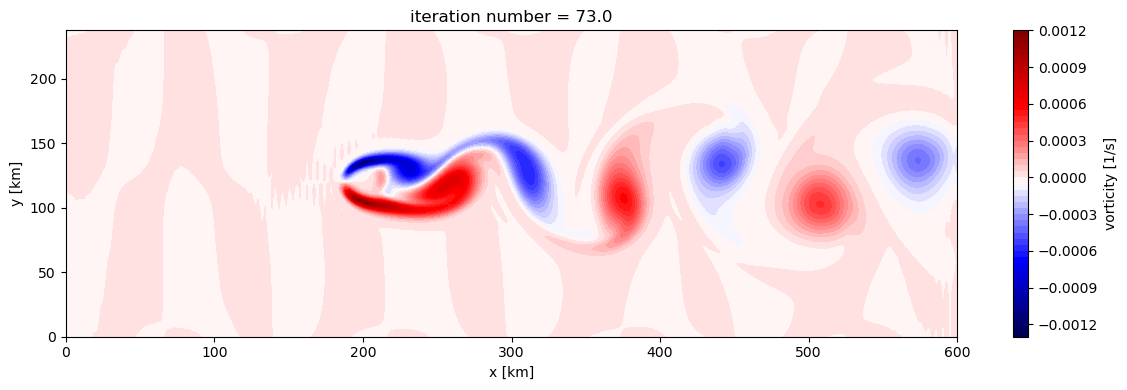

37000


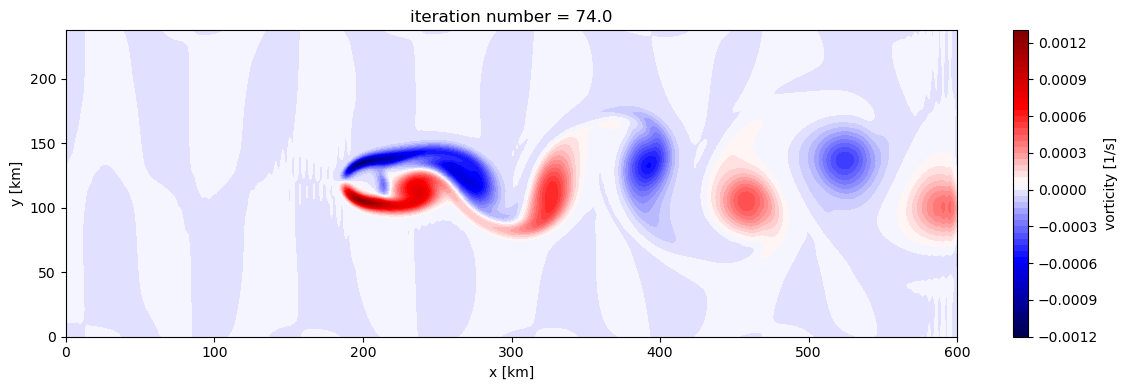

37500


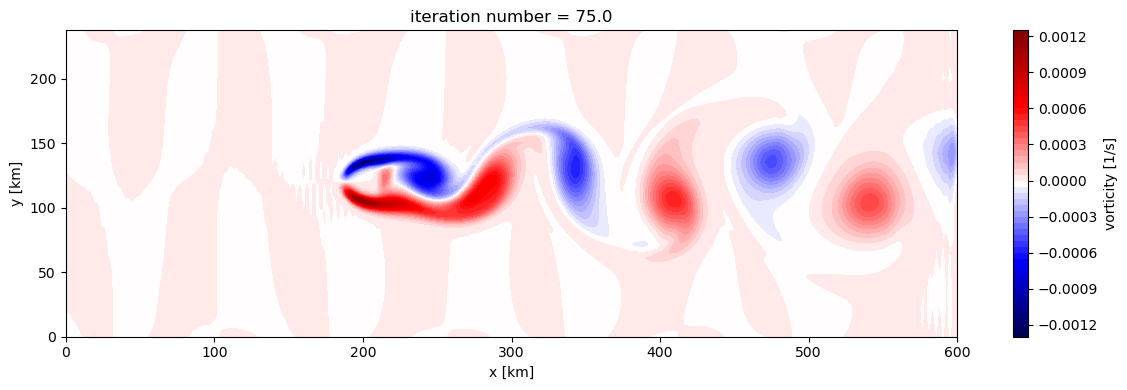

38000


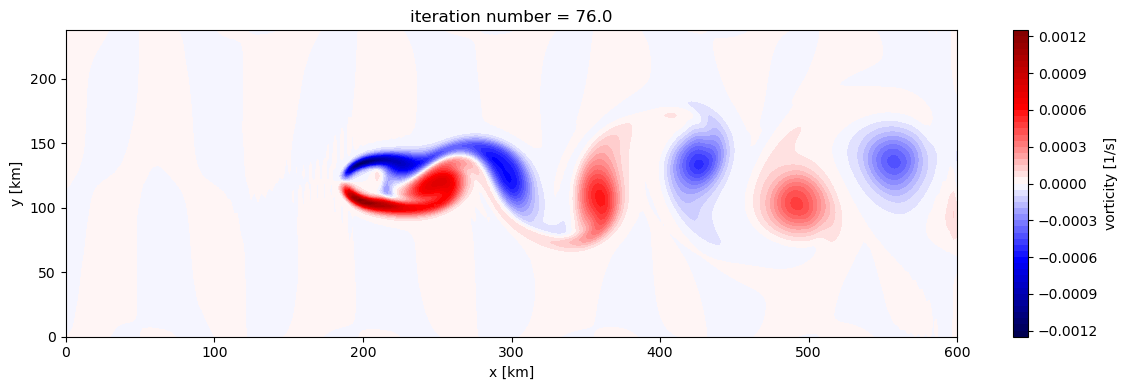

38500


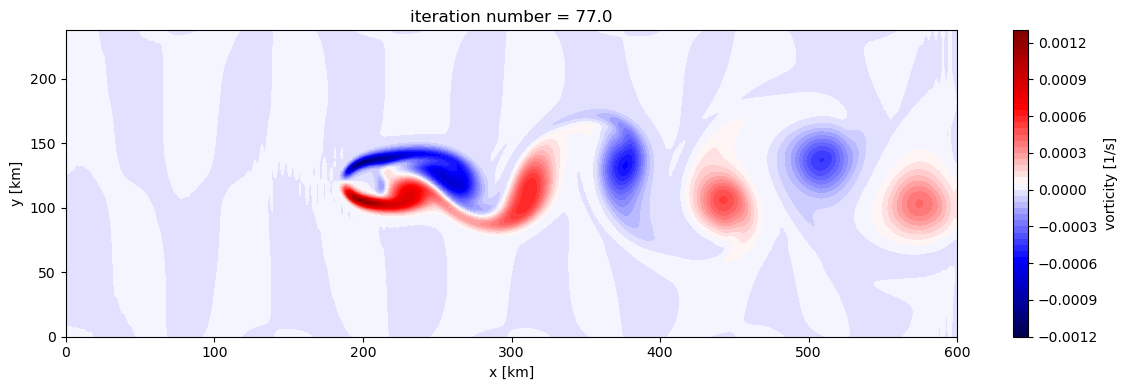

39000


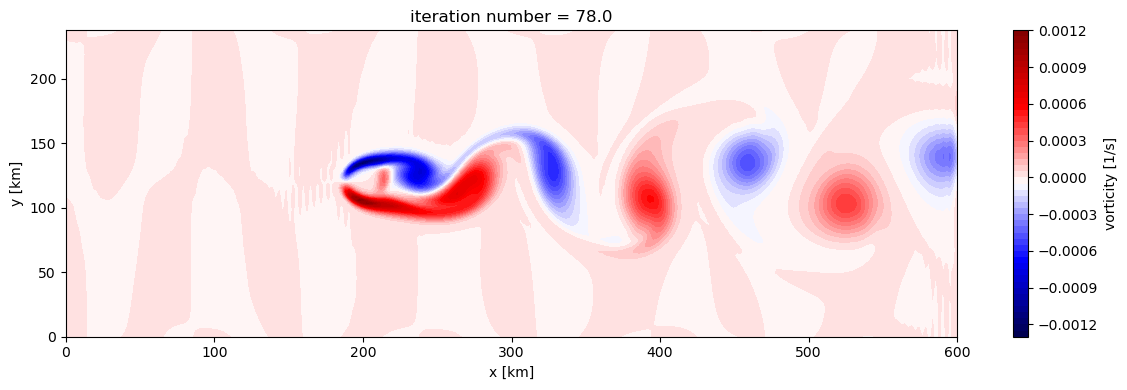

39500


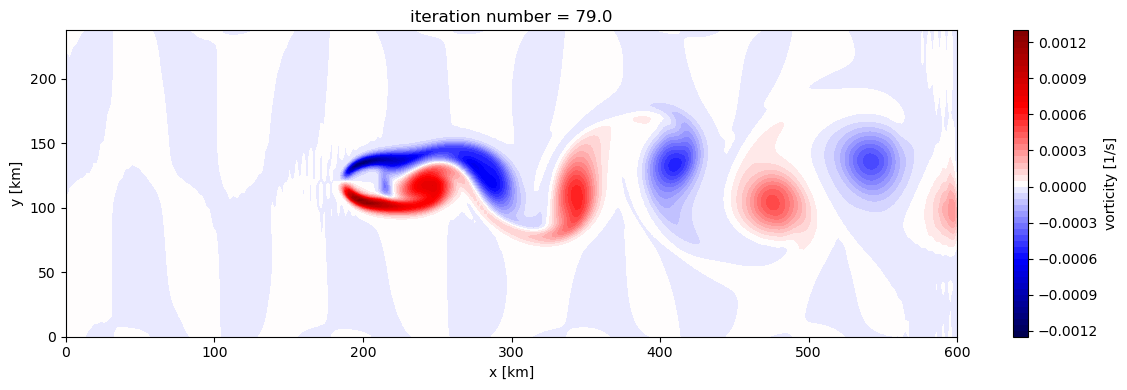

40000


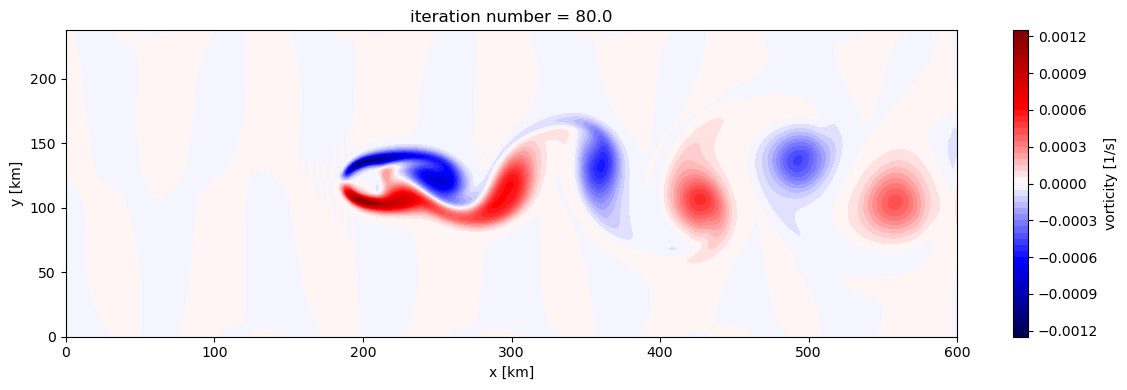

40500


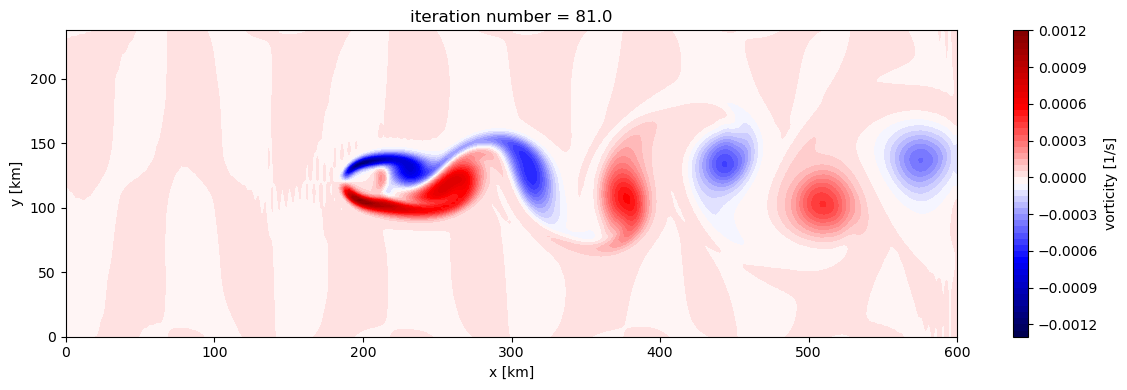

41000


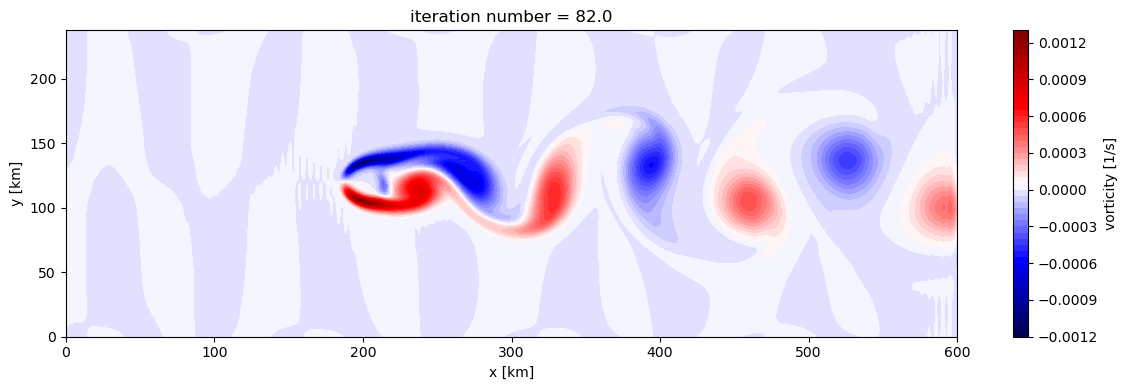

41500


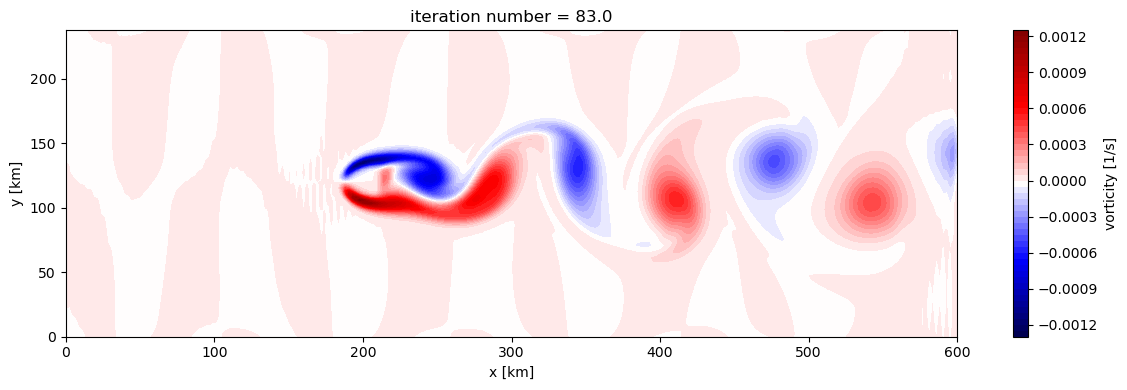

42000


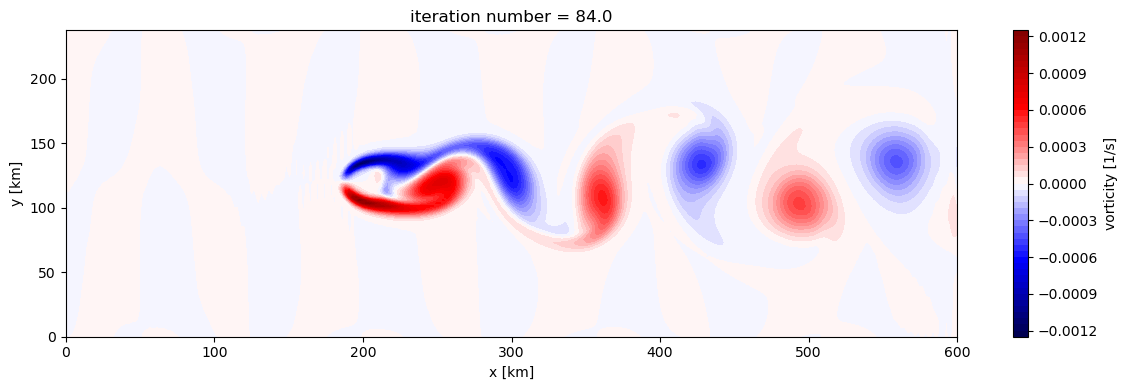

42500


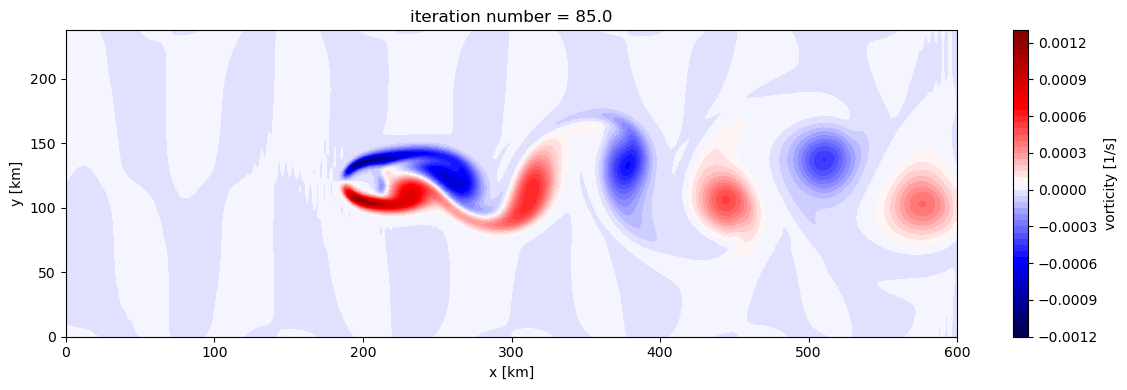

43000


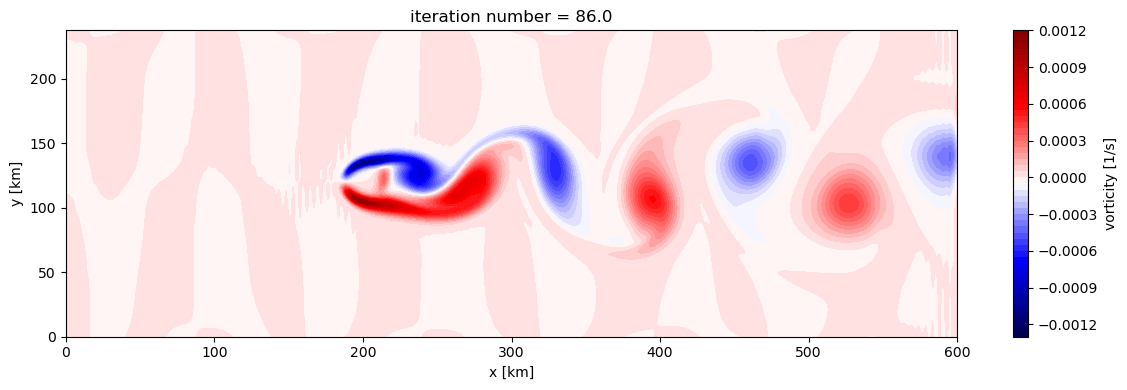

43500


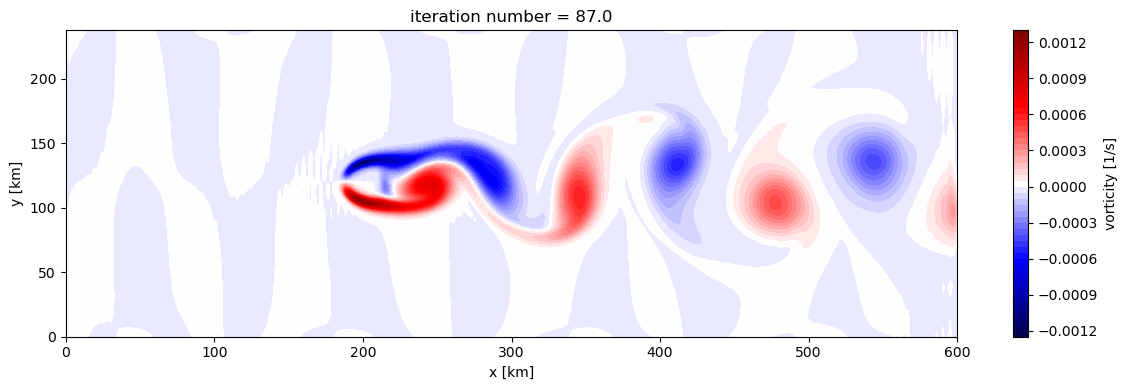

44000


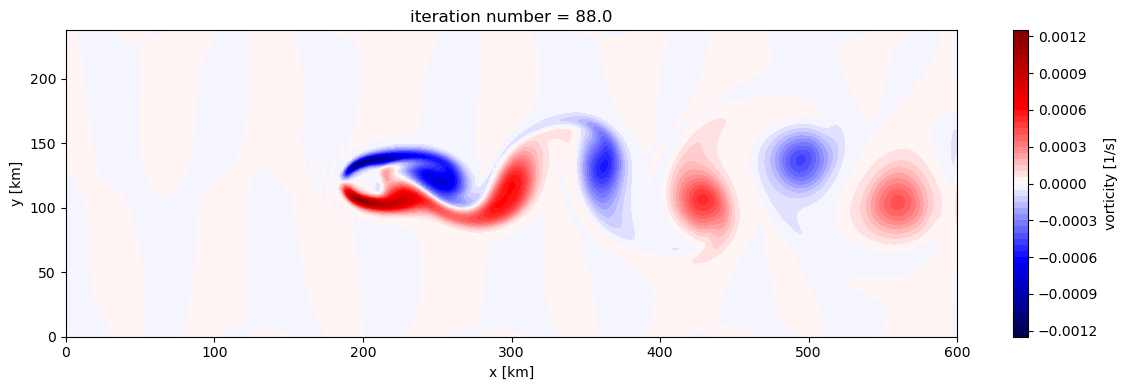

44500


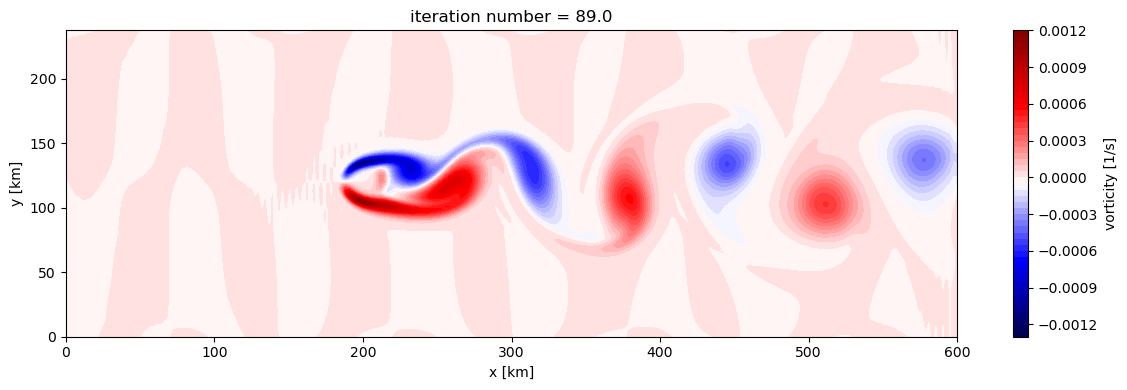

45000


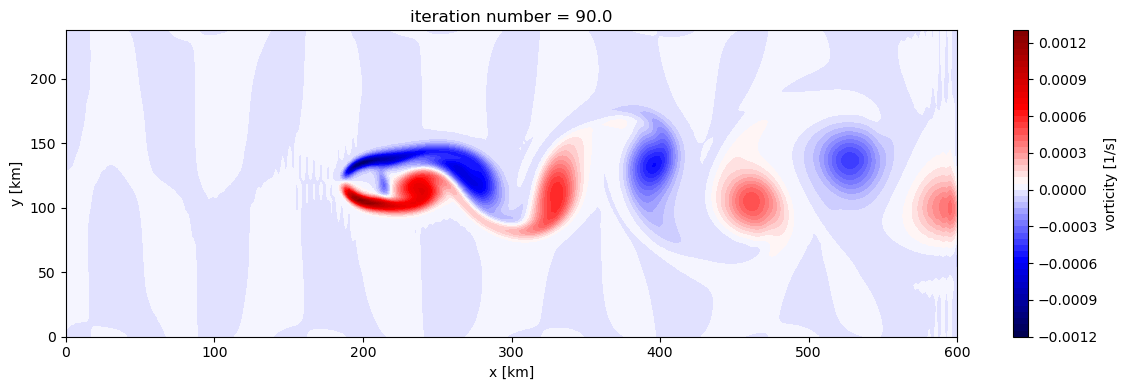

45500


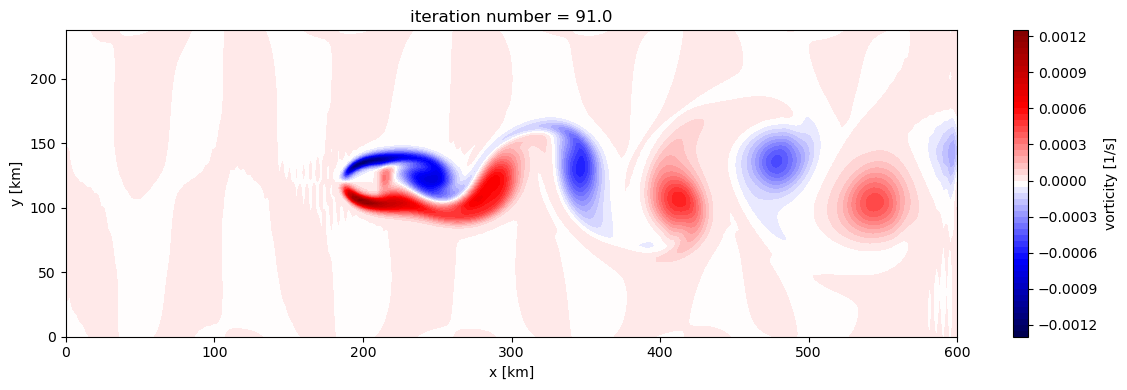

46000


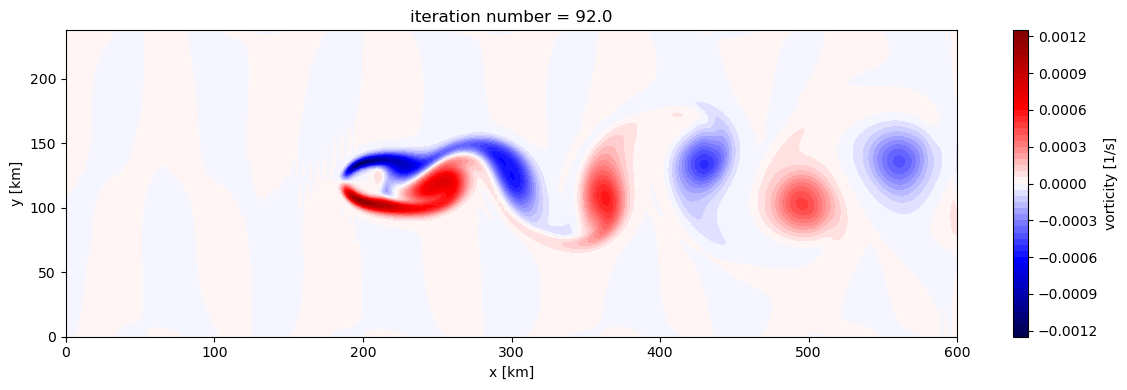

46500


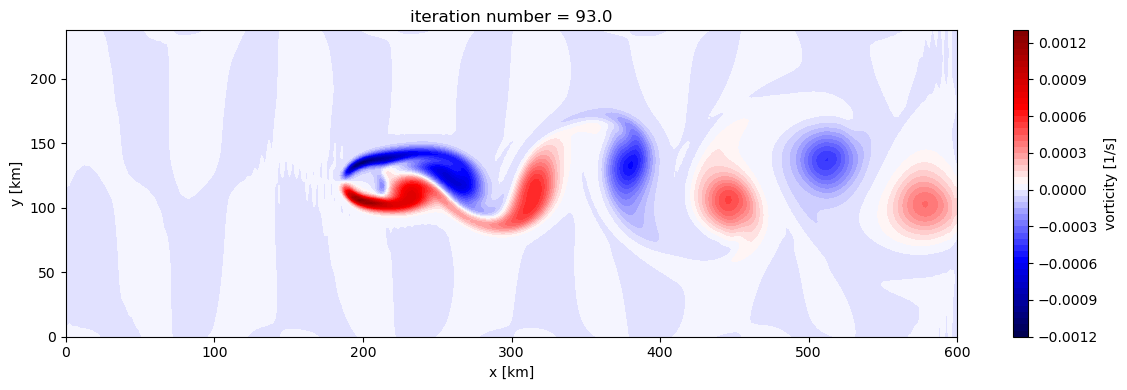

47000


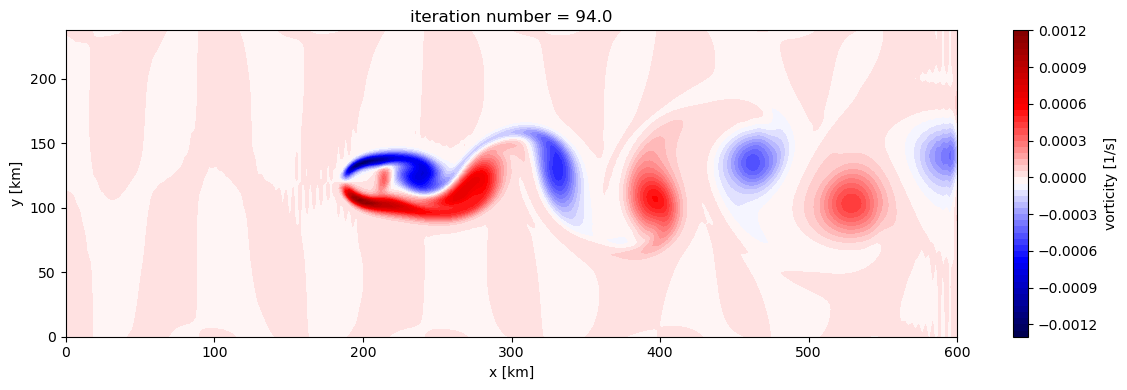

47500


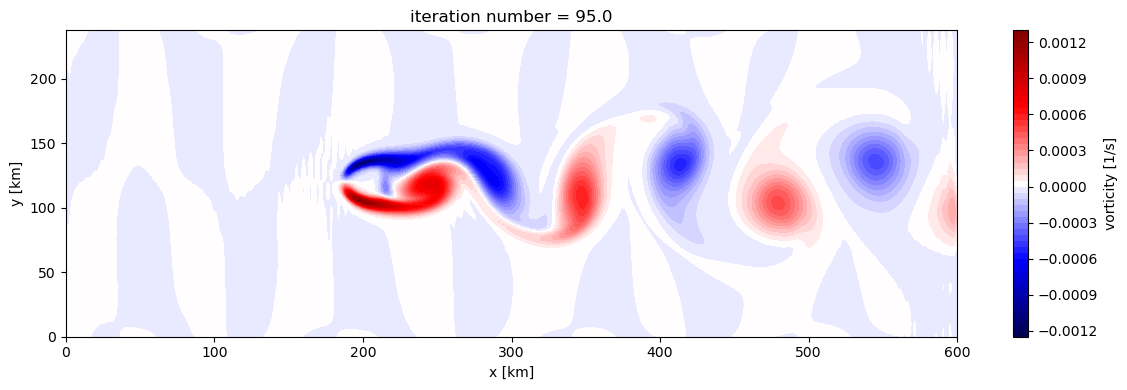

48000


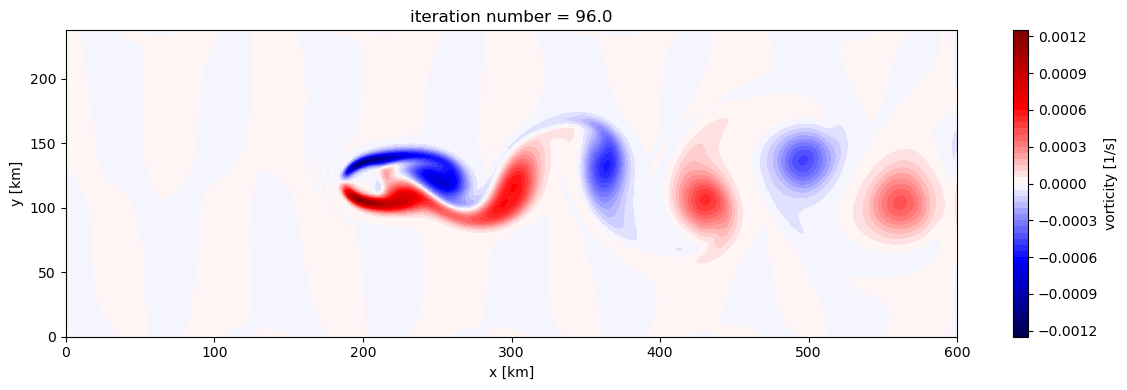

48500


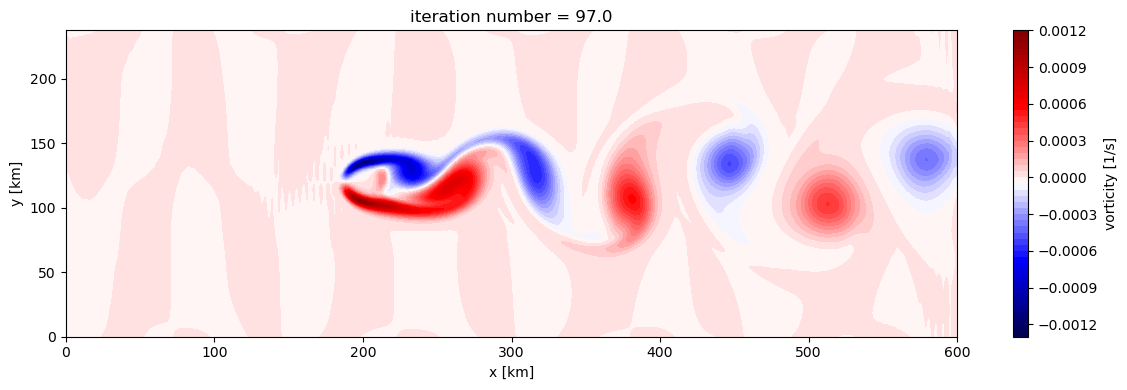

49000


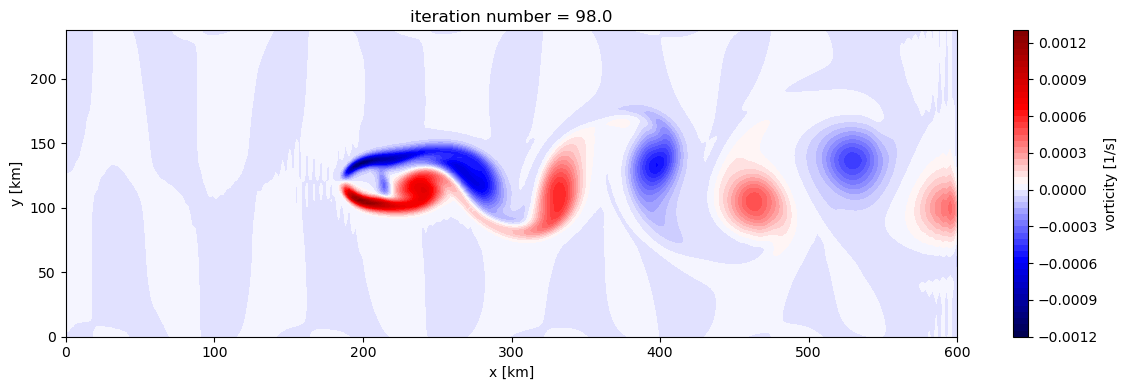

49500


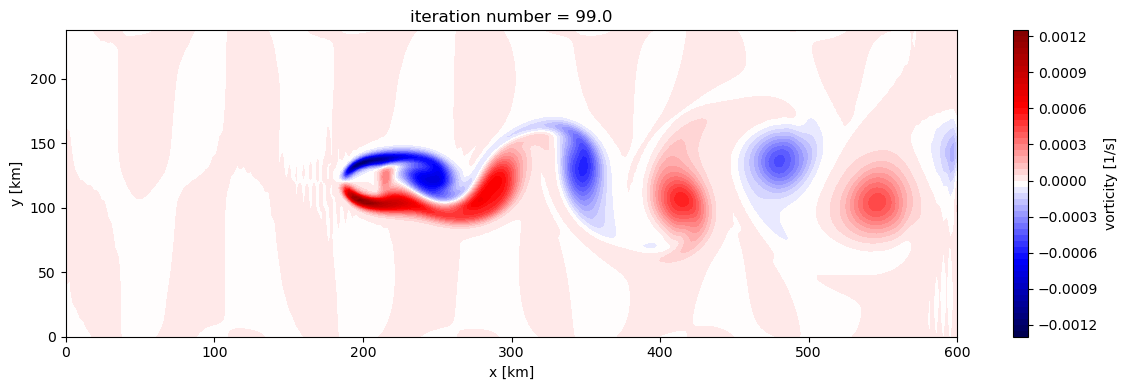

50000


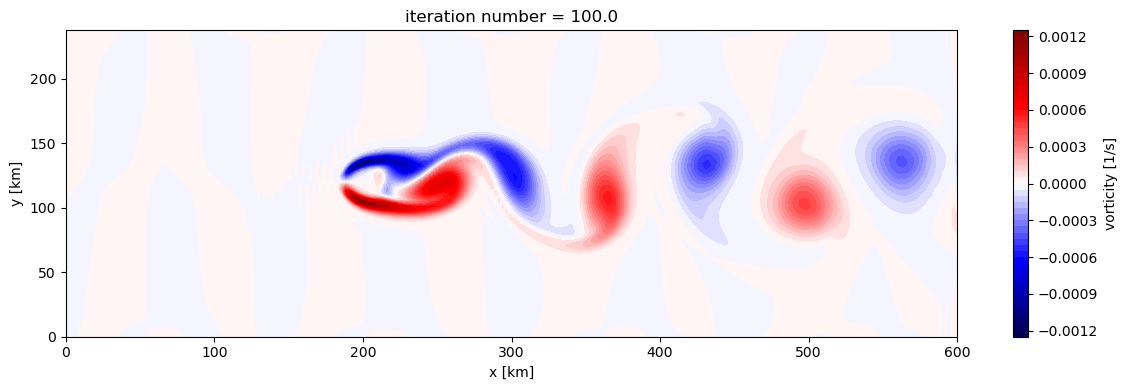

50500


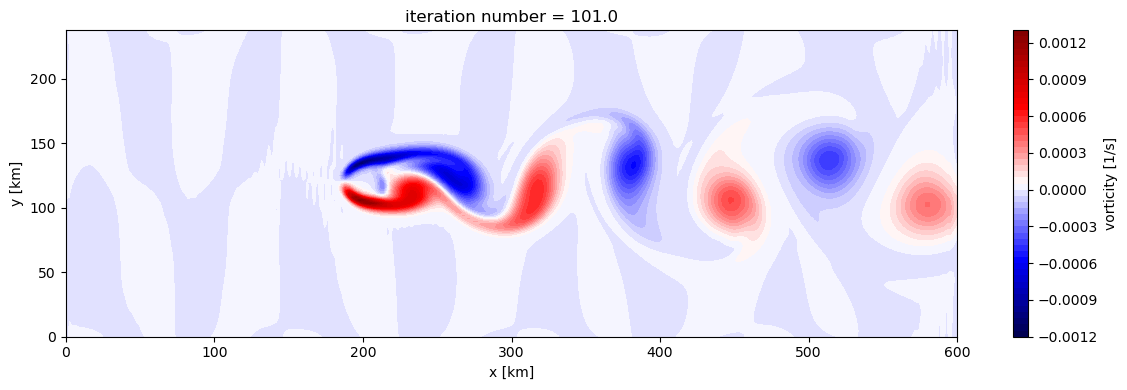

51000


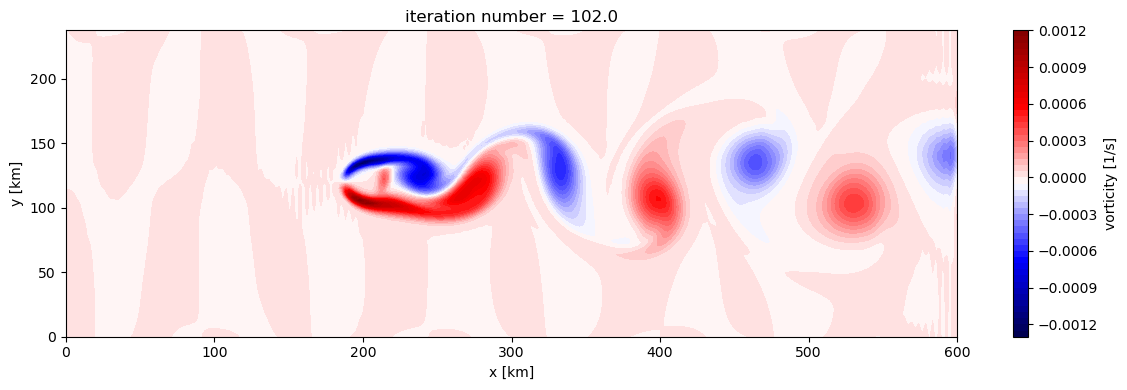

51500


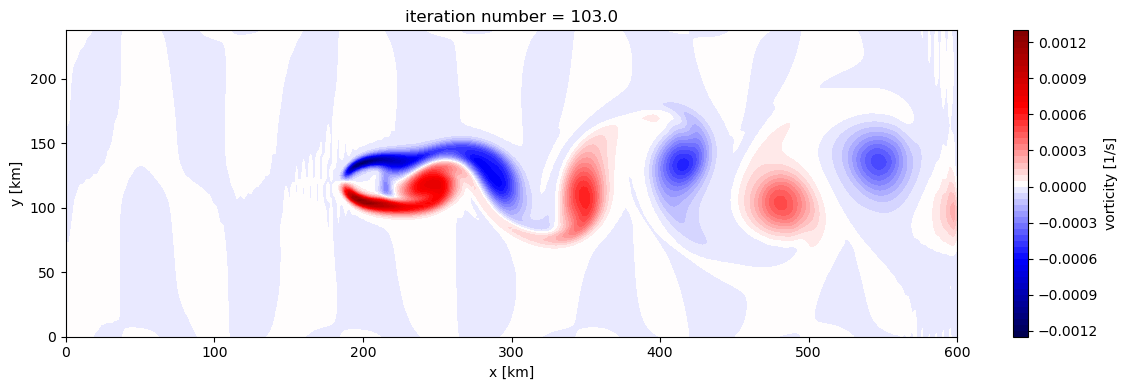

52000


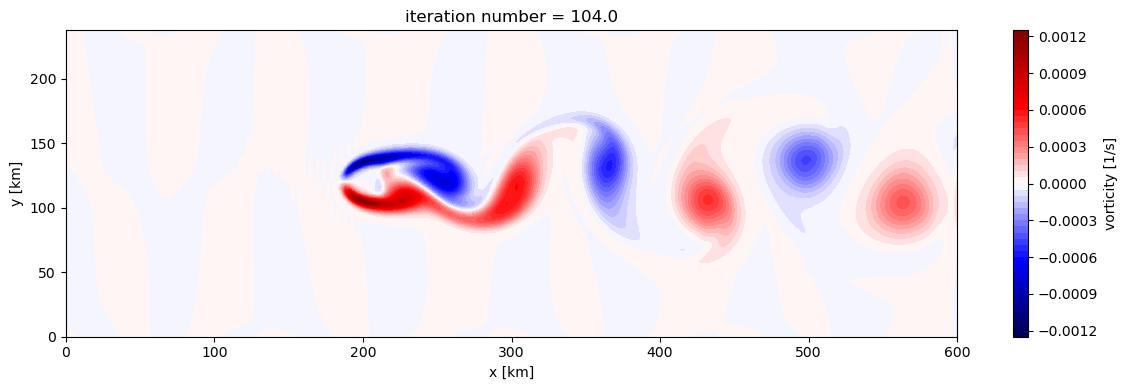

52500


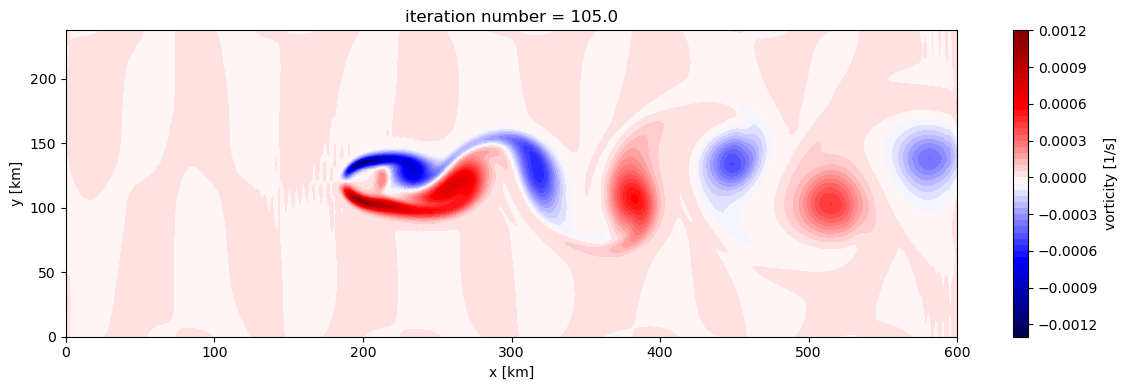

53000


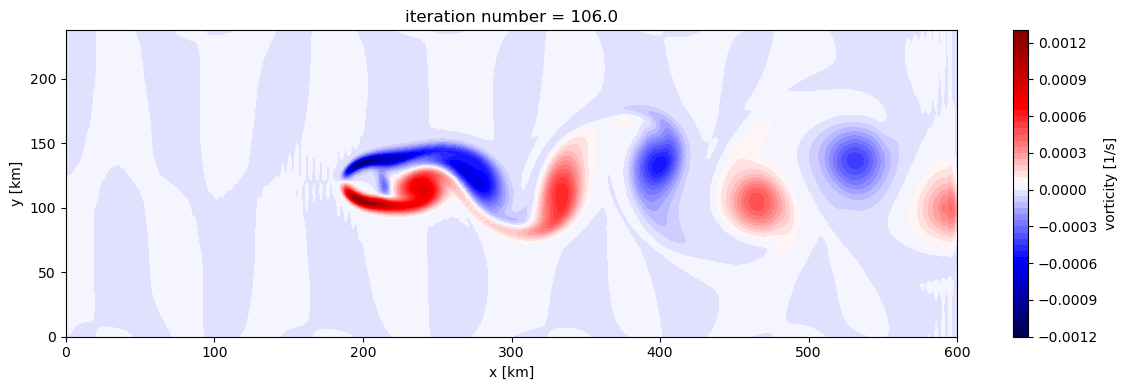

53500


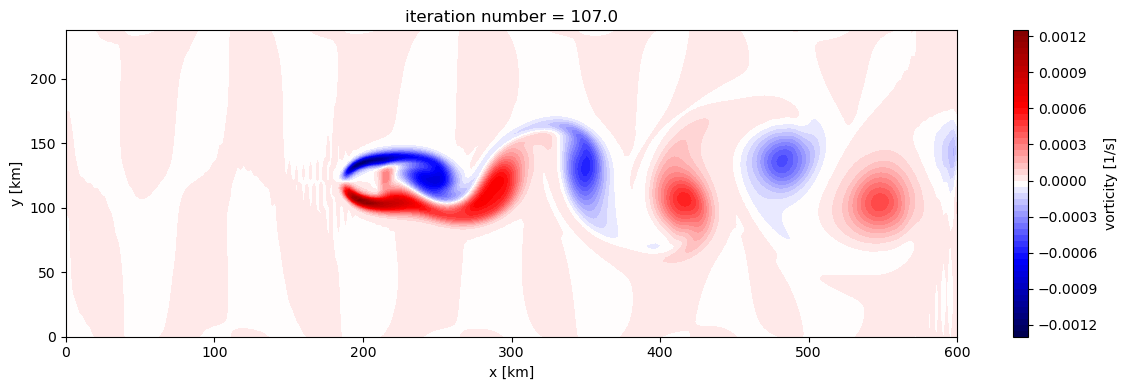

54000


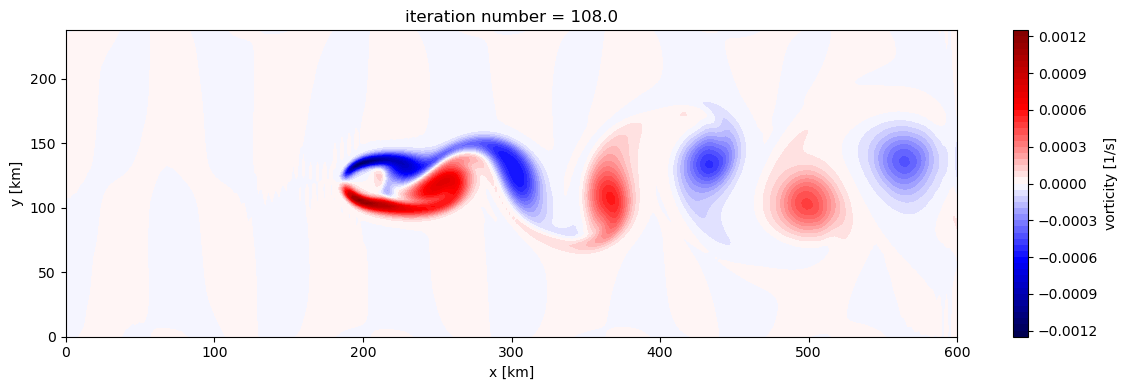

54500


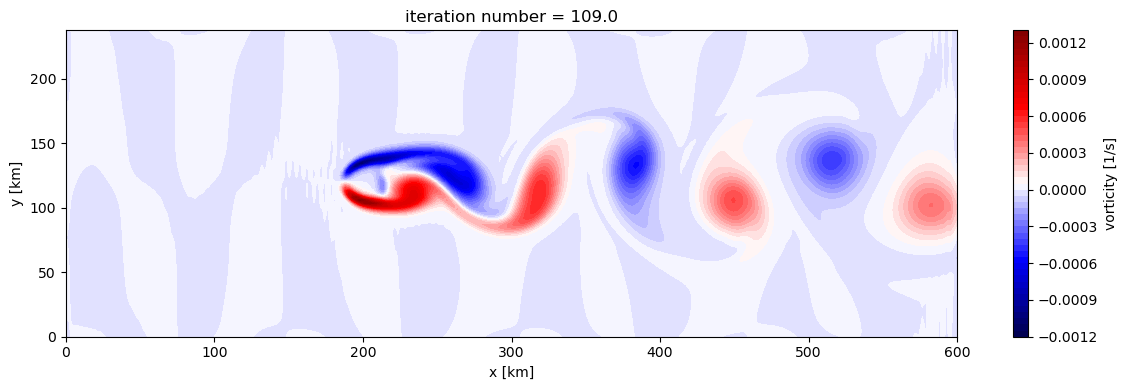

55000


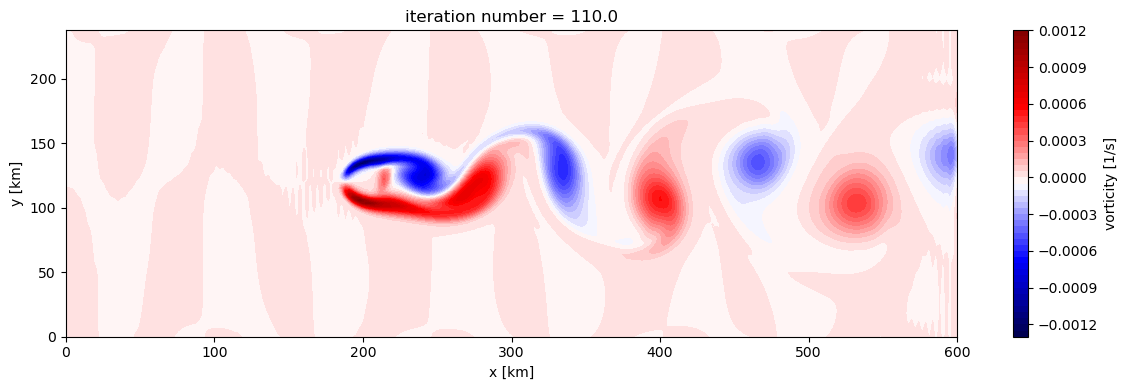

55500


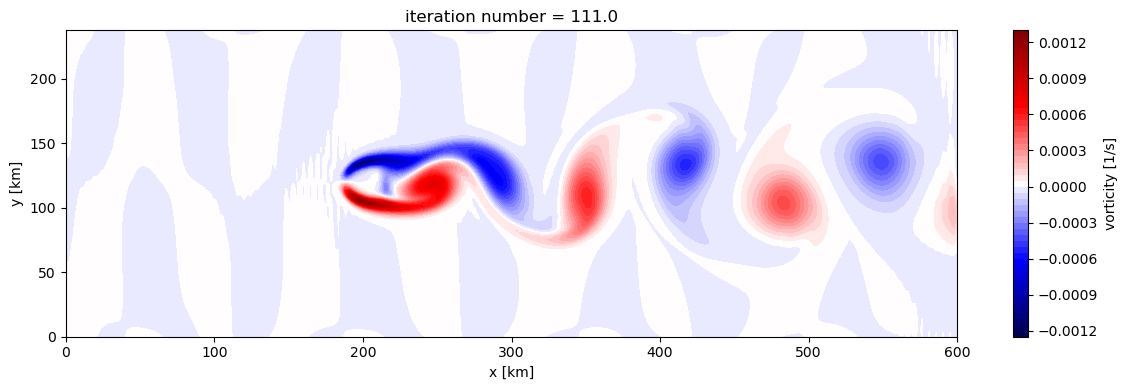

56000


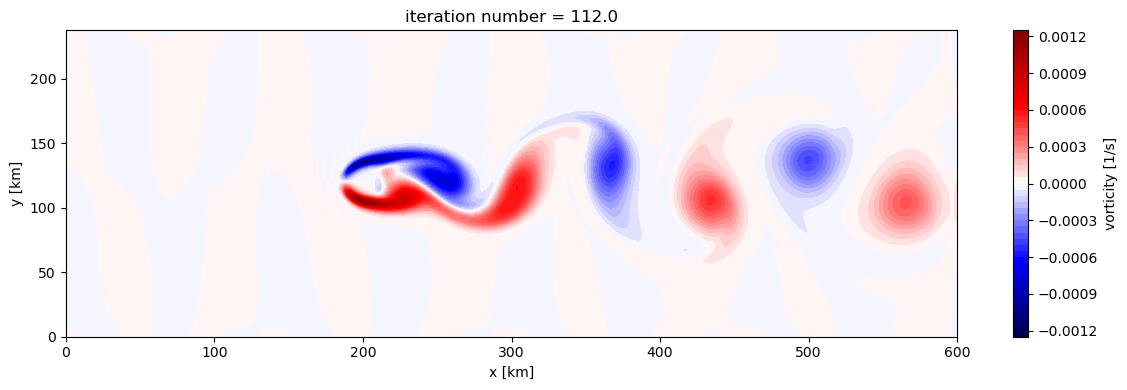

56500


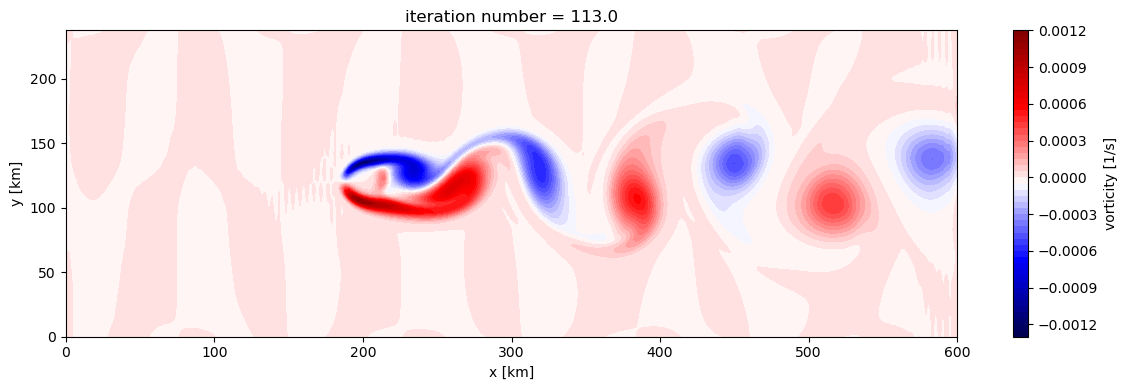

57000


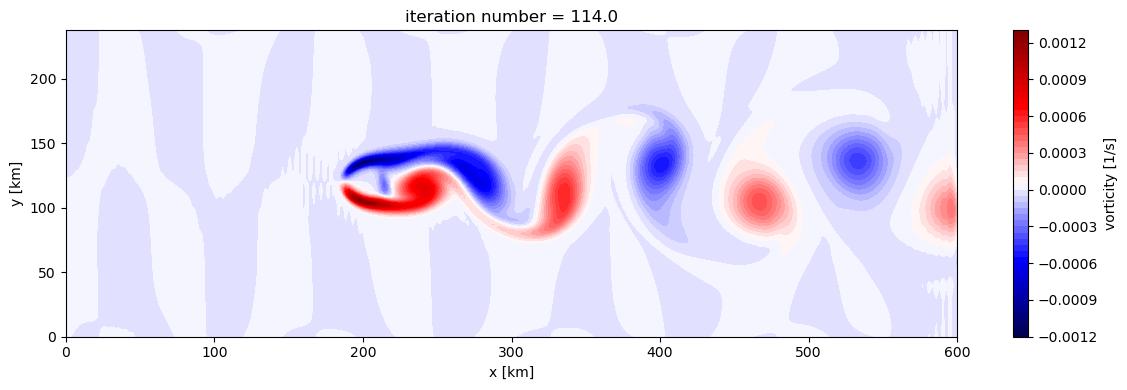

57500


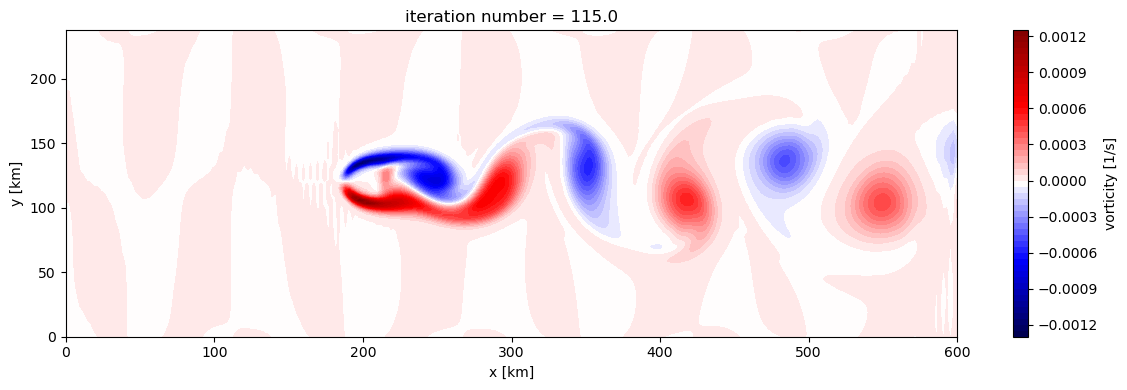

58000


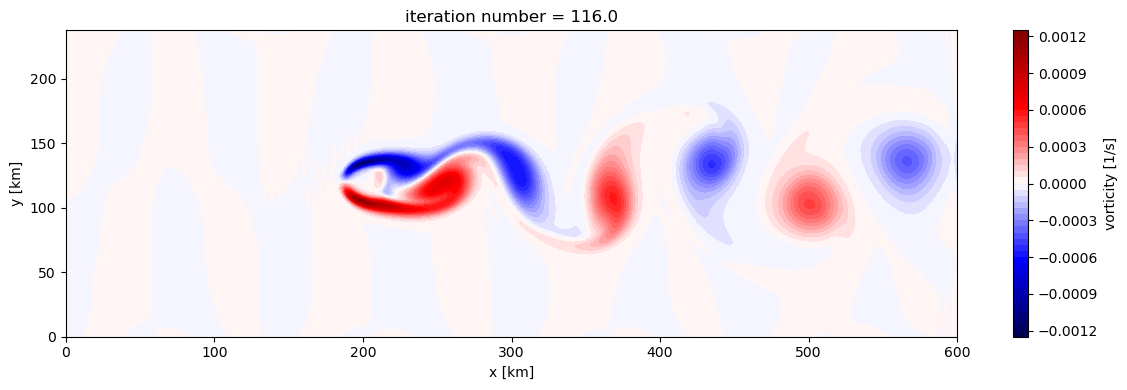

58500


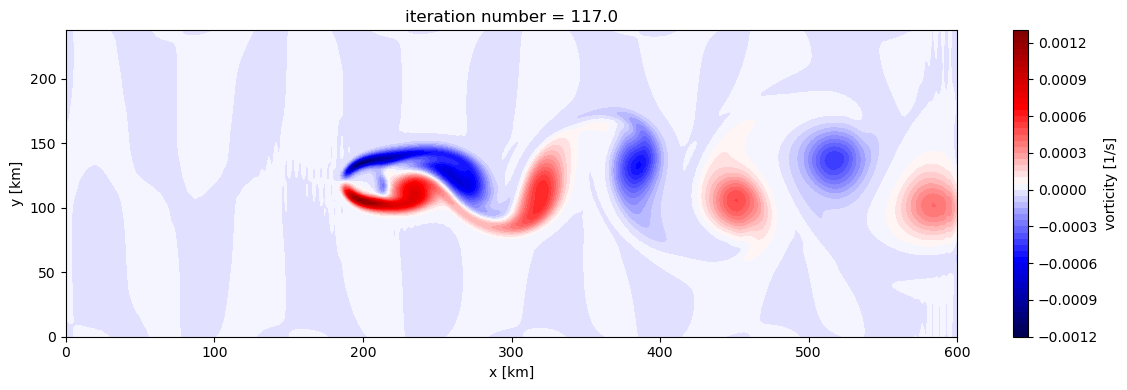

59000


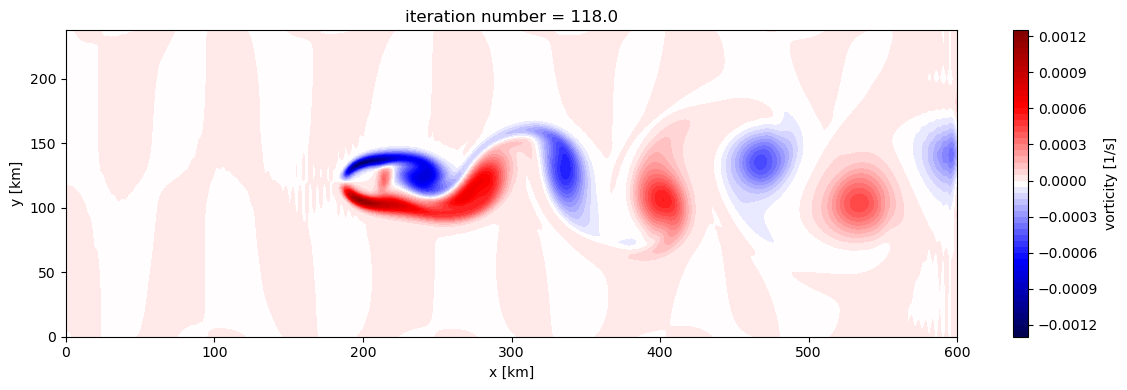

59500


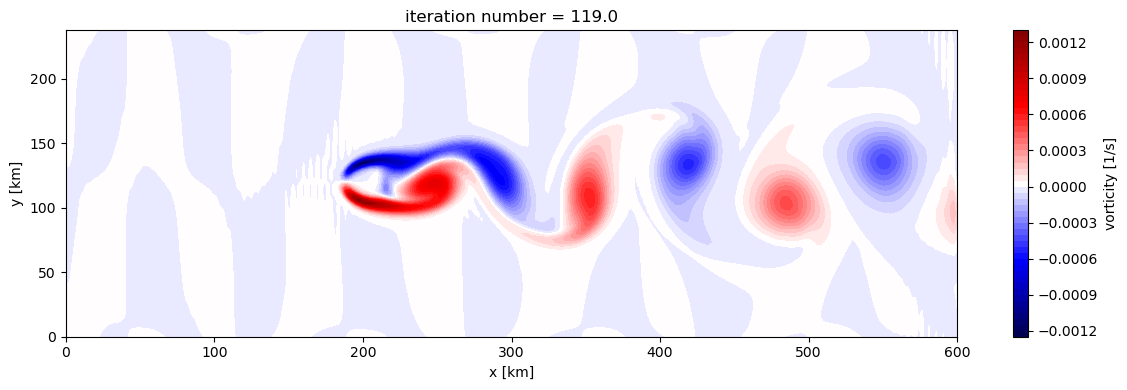

(array([[1000.        , 1427.51325797, 1019.11508088, ..., 1220.07516014,
         1220.86786177, 1220.86786177],
        [1000.        , 1427.38508709, 1019.11423652, ..., 1217.45446197,
         1218.09772916, 1218.09772916],
        [1000.        , 1427.30308462, 1019.11671546, ..., 1214.7894082 ,
         1215.27763531, 1215.27763531],
        ...,
        [1000.        , 1428.16645804, 1019.13359095, ..., 1227.59790757,
         1228.80736819, 1228.80736819],
        [1000.        , 1427.90516925, 1019.12541035, ..., 1225.15390483,
         1226.22945887, 1226.22945887],
        [1000.        , 1427.68672016, 1019.11902329, ..., 1222.64407958,
         1223.58079511, 1223.58079511]]),
 array([[8.        , 5.17222958, 7.22103415, ..., 6.62641547, 6.627811  ,
         6.627811  ],
        [8.        , 5.17313896, 7.22114381, ..., 6.67031053, 6.67156464,
         6.67156464],
        [8.        , 5.17347457, 7.22117615, ..., 6.7139963 , 6.71510242,
         6.71510242],
        ...,


In [28]:
update_rk2(h,u,v)


In [40]:
import matplotlib.animation as animation

# same loop but save frames instead of showing plots
def update_rk2_anim(h, u, v, steps=60000):
    zeta_frames = []

    for n in range(steps):
        h, u, v = rk2_step(h, u, v)
        h, u, v = boundary_conditions(h, u, v)

        if n % 100 == 0:
            zeta = ddx(v) - ddy(u)
            zeta_frames.append(zeta.copy())
            

    return h, u, v, zeta_frames


In [30]:
# reset fields to initial state
rng2 = np.random.default_rng(0)
h = np.full((Ny, Nx), H0)
u = np.full((Ny, Nx), U0) + 1*1e-3*U0 * rng2.standard_normal((Ny, Nx))
v = np.zeros((Ny, Nx)) + 1*1e-3*U0 * rng2.standard_normal((Ny, Nx))

# run simulation and collect frames
h, u, v, zeta_frames = update_rk2_anim(h, u, v)
print("done! frames collected:", len(zeta_frames))


done! frames collected: 600


saved vorticity_animation.gif


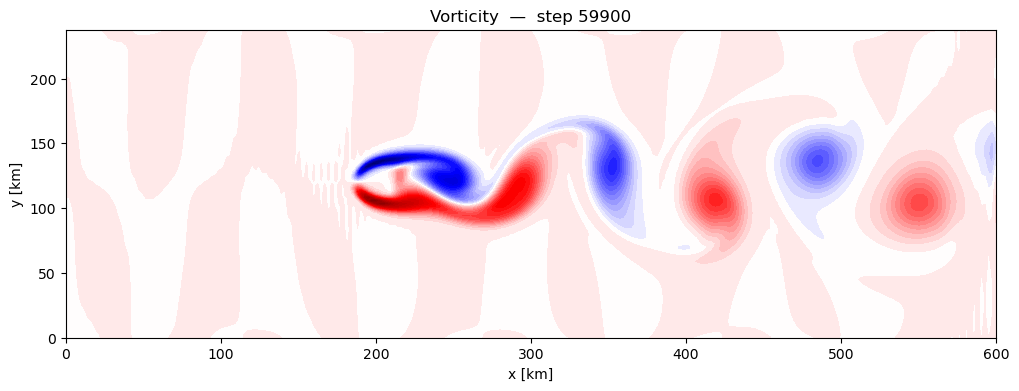

In [31]:
# build animation from saved frames
fig, ax = plt.subplots(figsize=(12, 4))

def draw_frame(i):
    ax.clear()
    ax.contourf(X/1e3, Y/1e3, zeta_frames[i], levels=50, cmap='seismic')
    ax.set_title(f"Vorticity  —  step {i * 100}")
    ax.set_xlabel('x [km]')
    ax.set_ylabel('y [km]')

anim = animation.FuncAnimation(fig, draw_frame, frames=len(zeta_frames), interval=150)

# save as gif 
anim.save('vorticity_animation.gif', writer='pillow', dpi=100)
anim.save('vorticity_animation.mp4', writer='ffmpeg', fps=24, dpi=120)
print("saved vorticity_animation.gif")
plt.show()


In [16]:

R0 = R0
xc = xc
yc = yc
v = v

x_wake, y_wake = (xc + 3*R0, yc + R0)

ix = np.argmin(np.abs(x - x_wake))
iy = np.argmin(np.abs(y-y_wake))



print(f"Wake point: x = {x[ix]/1e3 }km, Wake point: y = {y[iy]/1e3} km ")

Wake point: x = 258.8235294117647km, Wake point: y = 138.8235294117647 km 


In [1]:
import numpy.fft

def cross_stream_v_at_xy(h, u, v, Nsteps=20000, save_every=100):
    t_wake_ts = []
    v_wake_ts = []

    for step in range(Nsteps):
        h, u, v = rk2_step(h, u, v)
        h, u, v = boundary_conditions(h, u, v)

        if step % save_every == 0:
            v_wake_ts.append(float(v[iy, ix]))
            t_wake_ts.append(dt * step)
            print(f"In step {step}")

    v_array = np.array(v_wake_ts)
    t_array = np.array(t_wake_ts)
    t_hours = t_array / 3600

    idx0 = np.searchsorted(t_hours, 5 * 24)

    t_cut = t_hours[idx0:]
    v_cut = v_array[idx0:]

    N = len(v_cut)
    dt_h = t_cut[1] - t_cut[0]
    freqs = np.fft.rfftfreq(N, d=dt_h)
    power = np.abs(np.fft.rfft(v_cut - v_cut.mean()))**2

    f_dom = freqs[np.argmax(power)]
    T_dom = 1 / f_dom

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))
    fig.suptitle(
        f"Wake point  ({x[ix]/1e3:.0f} km, {y[iy]/1e3:.0f} km)",
        fontsize=13, fontweight='bold'
    )

    ax1.plot(t_cut, v_cut, color='steelblue', linewidth=1.1)
    ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax1.set_xlabel("Time  [h]")
    ax1.set_ylabel("v  [m/s]")
    ax1.set_title("Cross-stream velocity (after 5-day spin-up)")
    ax1.grid(True, alpha=0.3)

    ax2.plot(freqs, power, color='darkorange', linewidth=1.1)
    ax2.axvline(f_dom, color='crimson', linewidth=1.1, linestyle='--',
                label=f"dominant  T = {T_dom:.1f} h")
    ax2.set_yscale("log")
    ax2.set_xlabel("Frequency  [cycles / h]")
    ax2.set_ylabel("Power  [(m/s)²]")
    ax2.set_title("Power spectrum of v")
    ax2.legend()
    ax2.grid(True, alpha=0.3, which='both')

    plt.tight_layout()
    plt.show()

    return t_cut, v_cut, freqs, power, f_dom, T_dom


In step 0
In step 100
In step 200
In step 300
In step 400
In step 500
In step 600
In step 700
In step 800
In step 900
In step 1000
In step 1100
In step 1200
In step 1300
In step 1400
In step 1500
In step 1600
In step 1700
In step 1800
In step 1900
In step 2000
In step 2100
In step 2200
In step 2300
In step 2400
In step 2500
In step 2600
In step 2700
In step 2800
In step 2900
In step 3000
In step 3100
In step 3200
In step 3300
In step 3400
In step 3500
In step 3600
In step 3700
In step 3800
In step 3900
In step 4000
In step 4100
In step 4200
In step 4300
In step 4400
In step 4500
In step 4600
In step 4700
In step 4800
In step 4900
In step 5000
In step 5100
In step 5200
In step 5300
In step 5400
In step 5500
In step 5600
In step 5700
In step 5800
In step 5900
In step 6000
In step 6100
In step 6200
In step 6300
In step 6400
In step 6500
In step 6600
In step 6700
In step 6800
In step 6900
In step 7000
In step 7100
In step 7200
In step 7300
In step 7400
In step 7500
In step 7600
In step 770

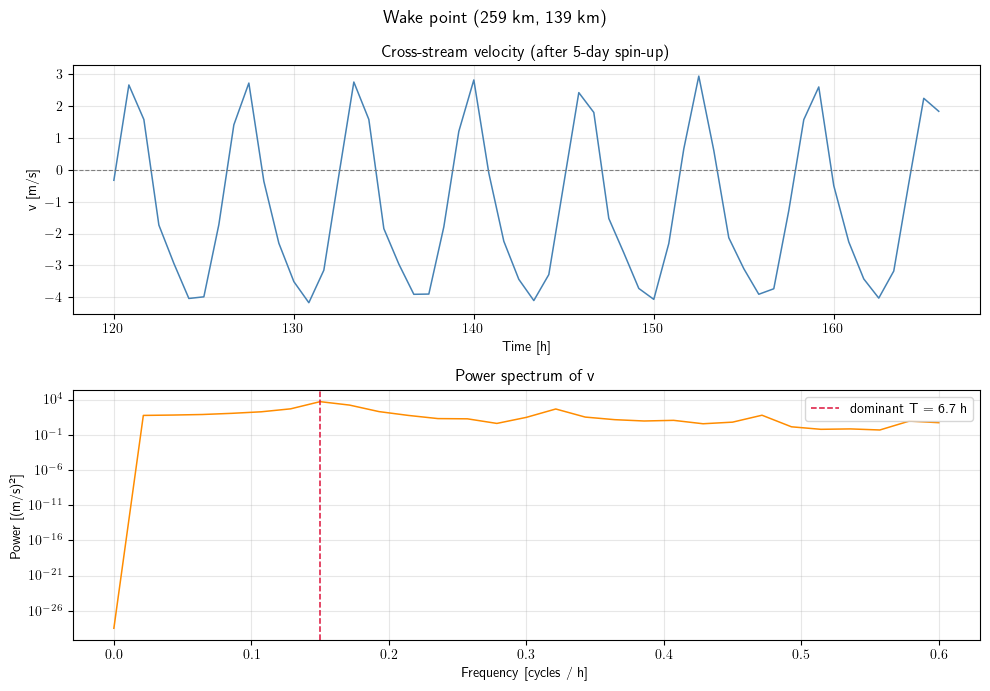

In [43]:
h = np.full (( Ny , Nx ) , H0 )
u = np.full (( Ny , Nx ) , U0 ) + 1*1e-3* U0 * rng.standard_normal (( Ny , Nx ) )
v = np.zeros (( Ny , Nx ) ) + 1*1e-3* U0 * rng.standard_normal (( Ny , Nx ) )
t_cut, v_cut, freqs, power, f_dom, T_dom = cross_stream_v_at_xy(h,u,v,Nsteps = 20000,  save_every = 100)

## What does $T \approx 6.7\,\text{h}$ mean?

The dominant period found in the wake is $T \approx 6.7\,\text{h}$. This is the time the flow takes to shed one vortex from the island — in other words, every 6.7 hours a new spinning patch of water detaches and travels downstream.

A classic way to describe this is with the **Strouhal number**:

$$St = \frac{f \cdot D}{U_0}$$

where $f = 1/T$ is the shedding frequency, $D = 2R_0 = 40\,\text{km}$ is the island diameter, and $U_0 = 8\,\text{m/s}$ is the inflow speed.

$$St = \frac{(1/6.7\,\text{h}) \cdot 40\,\text{km}}{8\,\text{m/s}} \approx \frac{4.14\times10^{-5}\,\text{s}^{-1} \cdot 4\times10^{4}\,\text{m}}{8\,\text{m/s}} \approx 0.21$$

A Strouhal number around $0.2$ is exactly what you get in a real Kármán vortex street — the simulation matches the known physics. The island acts like a bluff body: it blocks the flow, and instead of the water going smoothly past, it wobbles side to side, releasing vortices alternately from each flank at this steady rhythm.

In step 0
In step 100
In step 200
In step 300
In step 400
In step 500
In step 600
In step 700
In step 800
In step 900
In step 1000
In step 1100
In step 1200
In step 1300
In step 1400
In step 1500
In step 1600
In step 1700
In step 1800
In step 1900
In step 2000
In step 2100
In step 2200
In step 2300
In step 2400
In step 2500
In step 2600
In step 2700
In step 2800
In step 2900
In step 3000
In step 3100
In step 3200
In step 3300
In step 3400
In step 3500
In step 3600
In step 3700
In step 3800
In step 3900
In step 4000
In step 4100
In step 4200
In step 4300
In step 4400
In step 4500
In step 4600
In step 4700
In step 4800
In step 4900
In step 5000
In step 5100
In step 5200
In step 5300
In step 5400
In step 5500
In step 5600
In step 5700
In step 5800
In step 5900
In step 6000
In step 6100
In step 6200
In step 6300
In step 6400
In step 6500
In step 6600
In step 6700
In step 6800
In step 6900
In step 7000
In step 7100
In step 7200
In step 7300
In step 7400
In step 7500
In step 7600
In step 770

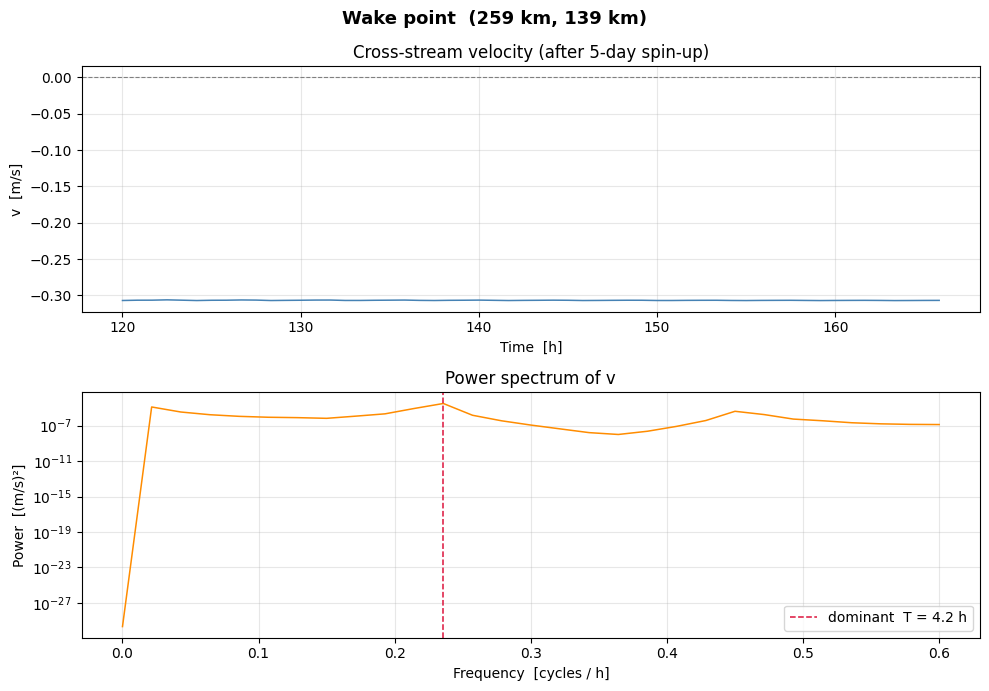

In [17]:
import numpy as np
nu = 5000
h = np.full (( Ny , Nx ) , H0 )
u = np.full (( Ny , Nx ) , U0 ) + 1*1e-3* U0 * rng.standard_normal (( Ny , Nx ) )
v = np.zeros (( Ny , Nx ) ) + 1*1e-3* U0 * rng.standard_normal (( Ny , Nx ) )
t_cut, v_cut, freqs, power, f_dom, T_dom = cross_stream_v_at_xy(h,u,v,Nsteps = 20000,  save_every = 100)